<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:brown;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
Car Price Prediction
</p>
</div>

<div style="font-family:Georgia;background-color:aliceblue; padding:30px; font-size:17px">

<b>Objective:- Car Price Prediction using Machine Learning.<br>

<b>Description</b><br>

💡 The price of a car depends on a lot of factors like the goodwill of the brand of the car,features of the car, horsepower and the mileage it gives and many more.<br>
💡 Car price prediction is one of the major research areas in machine learning.<br>
💡 In this assignment we have to train a machine learning model which will predict the price of cars using the given features of car.<br>
💡 Dataset Link:- https://www.khmer24.com/en/cars/all-cars.html<br>
 
<a id="1.3"></a>
<h2 style="font-family: Verdana; font-size: 22px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: black; background-color:aliceblue;"><b> Author:- </b> SOBON MENGHORNG</h2>
</div> 

In [263]:
%pip install plotly


Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


# Table of Contents
<a id="toc"></a>
- [1. Introduction](#1)
- [2. Imports](#2)
- [3. Data Loading](#3)
    - [3.1 Basic Understanding](#3.1)
    - [3.2 Data clearning](#3.2)
- [4. EDA](#4)
    - [4.1 Overview of Data](#4.1)
    - [4.2 Null Value Distribution](#4.7)
    - [4.3 Continuos and Categorical Data Distribution](#4.2)
    - [4.4 Feature Distribution of Continous Features](#4.3)
    - [4.5 Feature Distribution of Categorical Features](#4.4)
    - [4.6 Target Distribution ](#4.5)
    - [4.7 Correlation Matrix ](#4.6)
- [5. Data Pre-Processing](#5)    
- [6. Modeling](#6)
    - [6.1 27 Different Classifiers ( LAZY PREDICT )](#6.1)
    - [6.2 LGBM Classifier](#6.2)
- [7. Submission](#7)   

<a id="1"></a>
# **<center><span style="color:#00BFC4;">Introduction  </span></center>**

<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana; line-height: 1.7em;">
    📌 &nbsp;<b><u>Car Price Prediction:</u></b><br>
 
The automobile market in Cambodia has been growing rapidly in recent years, with an increasing number of car buyers seeking to purchase new and used cars. As a result, there has been a growing interest in determining the factors that influence car prices in Cambodia. In this study, we aim to explore the relationship between various car features and their impact on car prices in the Cambodian market.

To achieve this goal, we collected data on car prices and features from Khmer24, one of the largest online marketplaces for cars in Cambodia. We scraped the data and compiled a dataset containing information on various car features such as make, model, year, and transmission type, as well as their corresponding prices.
</div>

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

In [264]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


In [265]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go 
pd.options.display.float_format = '{:.4f}'.format

from statsmodels.stats.outliers_influence import variance_inflation_factor

from IPython.display import clear_output
# !pip3 install -U lazypredict
# !pip3 install -U pandas #Upgrading pandas

clear_output()

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:black;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
<a id="3"></a>
<span style="color:#00BFC4;">Data Loading</span>
</p>
</div>

In [266]:
# Read data
cars = pd.read_csv('Car_Kh24.csv')
cars.head(3)

RANDOM_STATE = 12 
FOLDS = 5
STRATEGY = 'median'

*Feature descriptions:*
>* **Ad ID**-The unique of cars in website khmer 24
>* **Category**- The type of cars in the website indicate for sale.
>* **Posted**- The date of this cars post in this website.
>* **Car Makes**- The brand of cars.
>* **Car Model**- The model of cars.
>* **Year**-The year that car create.

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:black;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
Basic Understanding of Data
</p>
</div>

### 1. Checking Dimensions of the Data. 

In [267]:
cars.shape

(17873, 16)

#### Observation
1. From the above output we can say that there are **17873 rows/records** and **16 columns/Features** present in our dataset

### 2. Checking the basic information of dataset. 

In [268]:
# Check some infomation
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17873 entries, 0 to 17872
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ad ID         17873 non-null  int64  
 1   Category      17873 non-null  object 
 2   Locations     17873 non-null  object 
 3   Posted        17873 non-null  object 
 4   Car Makes     17870 non-null  object 
 5   Car Model     17750 non-null  object 
 6   Year          17871 non-null  float64
 7   Tax Type      17873 non-null  object 
 8   Condition     17873 non-null  object 
 9   Body Type     14215 non-null  object 
 10  Fuel          15712 non-null  object 
 11  Transmission  16387 non-null  object 
 12  Color         17685 non-null  object 
 13  Link          17873 non-null  object 
 14  Title         17873 non-null  object 
 15  Price         17873 non-null  object 
dtypes: float64(1), int64(1), object(14)
memory usage: 2.2+ MB


#### Observation
1. From above output we can observe that **14 categorical** & **2 numerical** Attributes.
2. Some feature is not correct data type. So we need to change.
3. By checking information we can see that there are some values was missing in some features

### 3. Checking NaN vaues in our Dataset 

In [269]:
# check missing values
print(f'\033[94m')
print(cars.isnull().sum())


Ad ID              0
Category           0
Locations          0
Posted             0
Car Makes          3
Car Model        123
Year               2
Tax Type           0
Condition          0
Body Type       3658
Fuel            2161
Transmission    1486
Color            188
Link               0
Title              0
Price              0
dtype: int64


#### Observation
> We have observe that **Car model**, **Year**, **Body Type**, **Fuel**, **Transmission**, and **Color** features are contain missing values. How we deal with these values will be very important.

In [270]:
%pip install nbformat --upgrade


Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


In [271]:
import plotly.graph_objects as go

# Get features with missing values
feature_has_missing_values = [feature for feature in cars.columns if cars[feature].isnull().any()]

# Get the count of missing values for each feature
missing_values = [cars[feature].isnull().sum() for feature in feature_has_missing_values]

# Add the count of rows with no missing values
none_missing = cars.shape[0] - sum(missing_values)

# Add 'None missing' label and value
feature_has_missing_values.append('None missing')
missing_values.append(none_missing)

# Create a pie chart
data = go.Pie(labels=feature_has_missing_values, values=missing_values)

# Layout for the chart
layout = go.Layout(title='Missing values with None missing values')

# Create the figure and show it
fig = go.Figure(data=data, layout=layout)
fig.show()


<details>
    
## Impact of Large Number of Missing Values

Having a large number of missing values in your dataset can significantly impact your analysis and the conclusions you draw from it. Here are some potential implications of having a large proportion of missing values in your dataset:

1. **Decreased accuracy:** Incomplete data can lead to biased or inaccurate results. If there is a large proportion of missing values, it may be difficult to accurately estimate the true values of the variables, and this can lead to inaccurate conclusions.

2. **Reduced representativeness:** If the missing values are not distributed uniformly across the dataset, the remaining data may not be representative of the population the dataset is supposed to represent. This can lead to biased results and incorrect conclusions.

3. **Reduced statistical power:** Missing data can reduce the statistical power of your analysis. This is because missing data can reduce the sample size, which in turn reduces the precision of estimates and increases the risk of type II errors.

4. **Difficulty in imputing missing values:** Imputing missing values can be difficult, especially when there is a large proportion of missing values. Imputing values that are not accurate can lead to further inaccuracies in the analysis.

Given the large proportion of missing values in your dataset, it is important to carefully consider how to handle them. This can involve exploring the reasons for the missingness and deciding on an appropriate imputation method or considering other methods for handling missing data, such as multiple imputation or using models that can handle missing data. Alternatively, if the missing values cannot be imputed or are too problematic, it may be necessary to exclude them from the analysis.

In summary, missing data can have a significant impact on your analysis, and it is important to carefully consider how to handle missing values in order to minimize bias and increase the accuracy of your results.
    </details>

### 4. Checking Duplicate Values. 

In [272]:
print('\033[94mDuplicate Values =',cars.duplicated().sum())

Duplicate Values = 6


#### Observation
>From the above output we can say that there is **6 duplicate** records present in our dataset.

In [273]:
# Handling duplicate values
cars.drop_duplicates(inplace= True)

### 5. Showing Only Categorical Features. 

In [274]:
df_categorical = cars.select_dtypes(include='object')
df_categorical.head(3)

,Category,Locations,Posted,Car Makes,Car Model,Tax Type,Condition,Body Type,Fuel,Transmission,Color,Link,Title,Price
0,Cars for Sale,Phnom Penh,10-Jun-23,Toyota,Highlander,Plate Number,Used,Sports,Petrol,Auto,Black,https://www.khmer24.com/en/cars/highlander-%E1...,Highlander ឆ្នាំ 2003 ម៉ាសុីន 4 ប៉ុង 1 ពណ័ ខ្មៅ,"$14,000"
1,Cars for Sale,Phnom Penh,09-Jun-23,Lexus,NX,Tax Paper,Used,NaN,Petrol,Auto,White,https://www.khmer24.com/en/cars/lexus-nx200t-2...,Lexus NX200T 2015 គុជ3,"$39,500"
2,Cars for Sale,Phnom Penh,09-Jun-23,Toyota,Land Cruiser,Plate Number,Used,SUV,Petrol,Auto,Black,https://www.khmer24.com/en/cars/%E1%9E%9B%E1%9...,លក់ Land Cruiser 2022,"$155,000"


### 6. Showing only the Numerical Features. 

In [275]:
df_numerical = cars.select_dtypes(exclude='object')
df_numerical.head(3)

,Ad ID,Year
0,9539303,2003.0000
1,9529408,2015.0000
2,9540392,2022.0000


### 7. Cardinality of Features.

In [276]:
print('\033[94m',cars.nunique())

 Ad ID           17867
Category            1
Locations          25
Posted             32
Car Makes          66
Car Model         515
Year               43
Tax Type            2
Condition           2
Body Type           9
Fuel                5
Transmission        2
Color              14
Link            17867
Title           15394
Price            1723
dtype: int64


### 8. Descriptive Statistics Analysis.

In [277]:
cars.describe(include='object')

,Category,Locations,Posted,Car Makes,Car Model,Tax Type,Condition,Body Type,Fuel,Transmission,Color,Link,Title,Price
count,17867,17867,17867,17864,17744,17867,17867,14211,15709,16382,17679,17867,17867,17867
unique,1,25,32,66,515,2,2,9,5,2,14,17867,15394,1723
top,Cars for Sale,Phnom Penh,10-Jun-23,Toyota,Prius,Plate Number,Used,SUV,Petrol,Auto,White,https://www.khmer24.com/en/cars/kia-carnival-2...,ឡានលក់,"$12,500"
freq,17867,15037,6298,8896,2918,13241,13908,5481,10061,15443,7350,1,646,255


> We will need to transform the data to be numeric (int64 or float64) so that we can train machine learning models. These models (in general) don't work on text.

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:black;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
<a id = '3.1'><span>Data Cleaning</span></a>
</p>
</div>

### 1. Cleaning the Price Feature. 

In [278]:
cars['Price'] = cars['Price'].apply(lambda x: x.split('$')[1].replace(',', '')).astype(float)
cars['Price'].dtype

dtype('float64')

### [2. Handling Missing Values](https://www.kaggle.com/code/sobonmenghorng/a-guide-to-handling-missing-values-in-python/edit) 
<br>
<details>
    
<h1> Handling Missing Values in Python </h1>
    

![](https://imgur.com/68u0dD2.png)

>Real world data is messy and often contains a lot of missing values. There could be multiple  reasons for the missing values but primarily the reason for missingness can be attributed to 

| Reason for missing Data |  
|--|
|Data doesn't exist  |  
|Data not collected due to human error.  |  
|Data deleted accidently  |  
|                         |

 Either way we need to address this issue before we  proceed with the modeling stuff. It is also important to note that some algorithms like `XGBoost` and `LightGBM` can treat missing data without any preprocessing.
<hr>
    </details>

#### Detecting missing data visually using Missingno library

>To graphically analyse the missingness of the data, let's use a library called [Missingno](https://github.com/ResidentMario/missingno) It is a package for graphical analysis of missing values. To use this library, we need to import it as follows: `import missingno as msno`

In [279]:
%pip install missingno

Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


<Axes: >

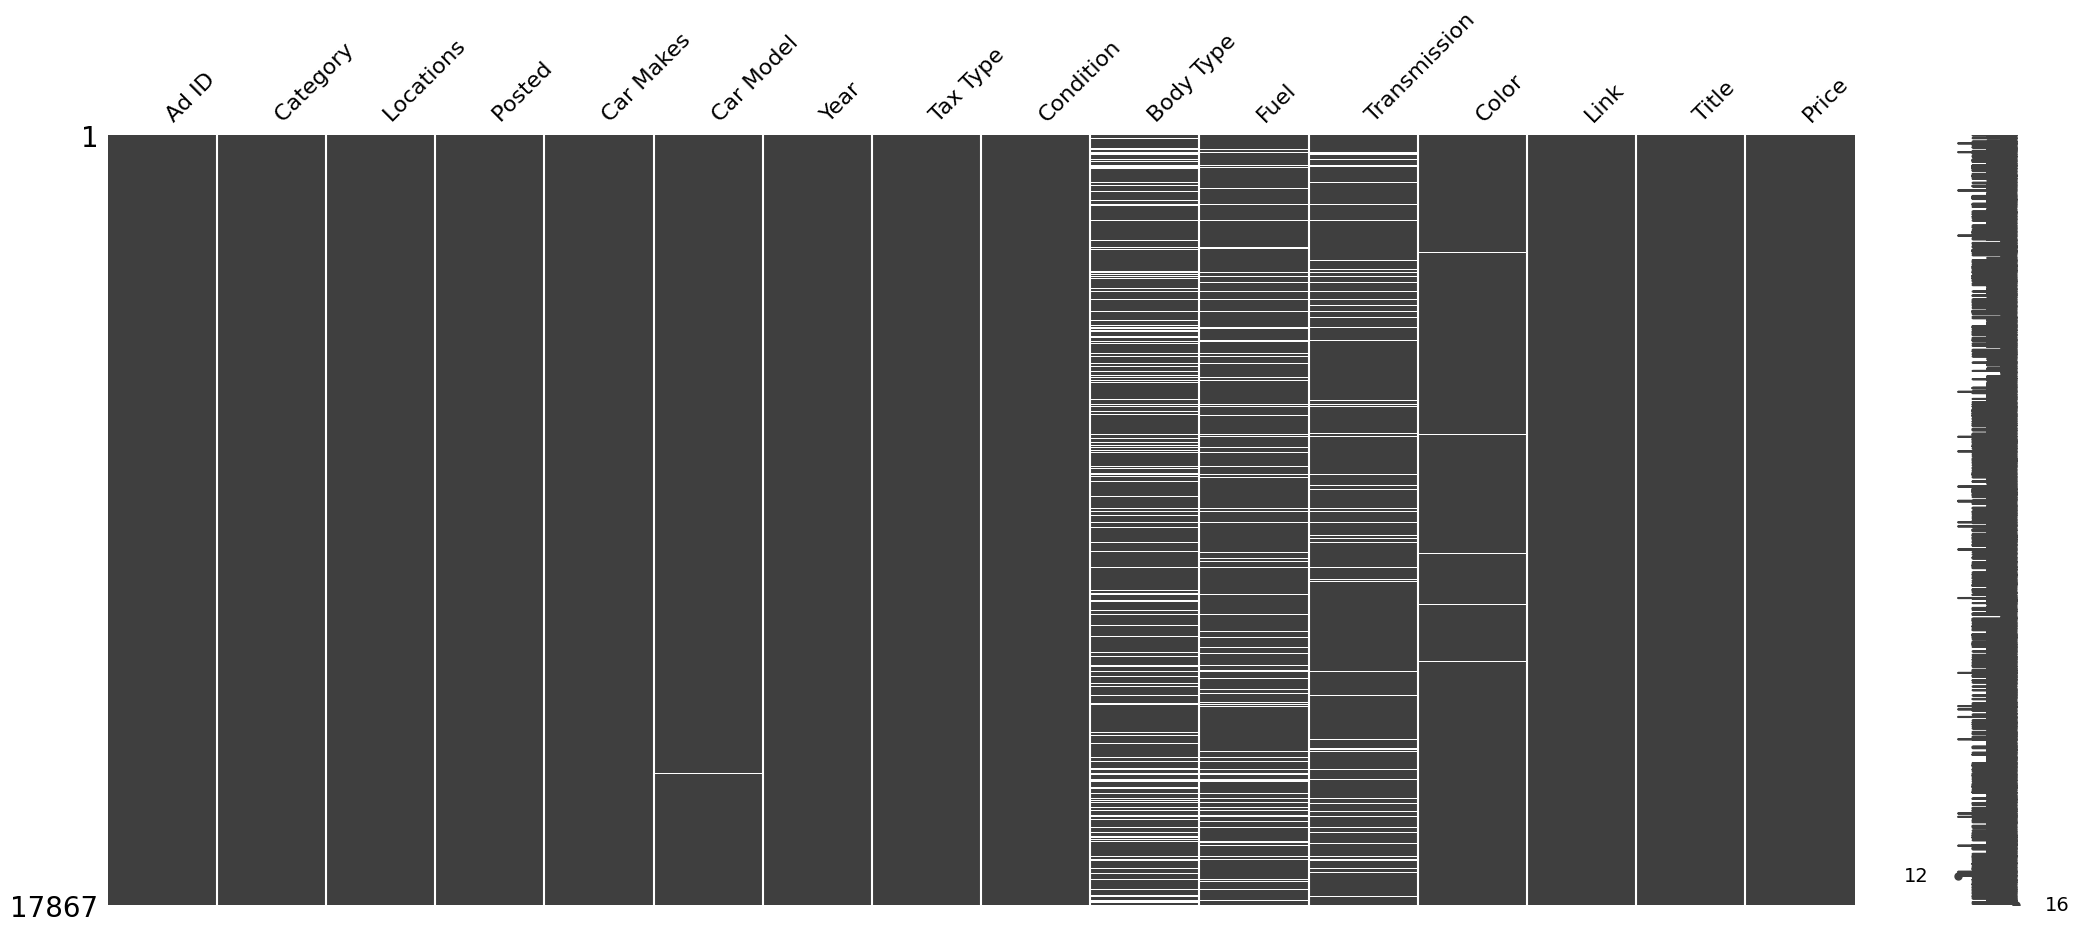

In [280]:
import missingno as msno

msno.matrix(cars)

>* The Color and Car Model Column has very few missing values and donot seem to be correlated with any other column, Hence, the missingness in of these column can be attributed as Missing Completely at Random.
>* Both the Body Type, Fuel and Transission columns have a lot of missing values.This could be a case of MAR as we cannot directly observe the reason for missingness of data in these columns.

<Axes: >

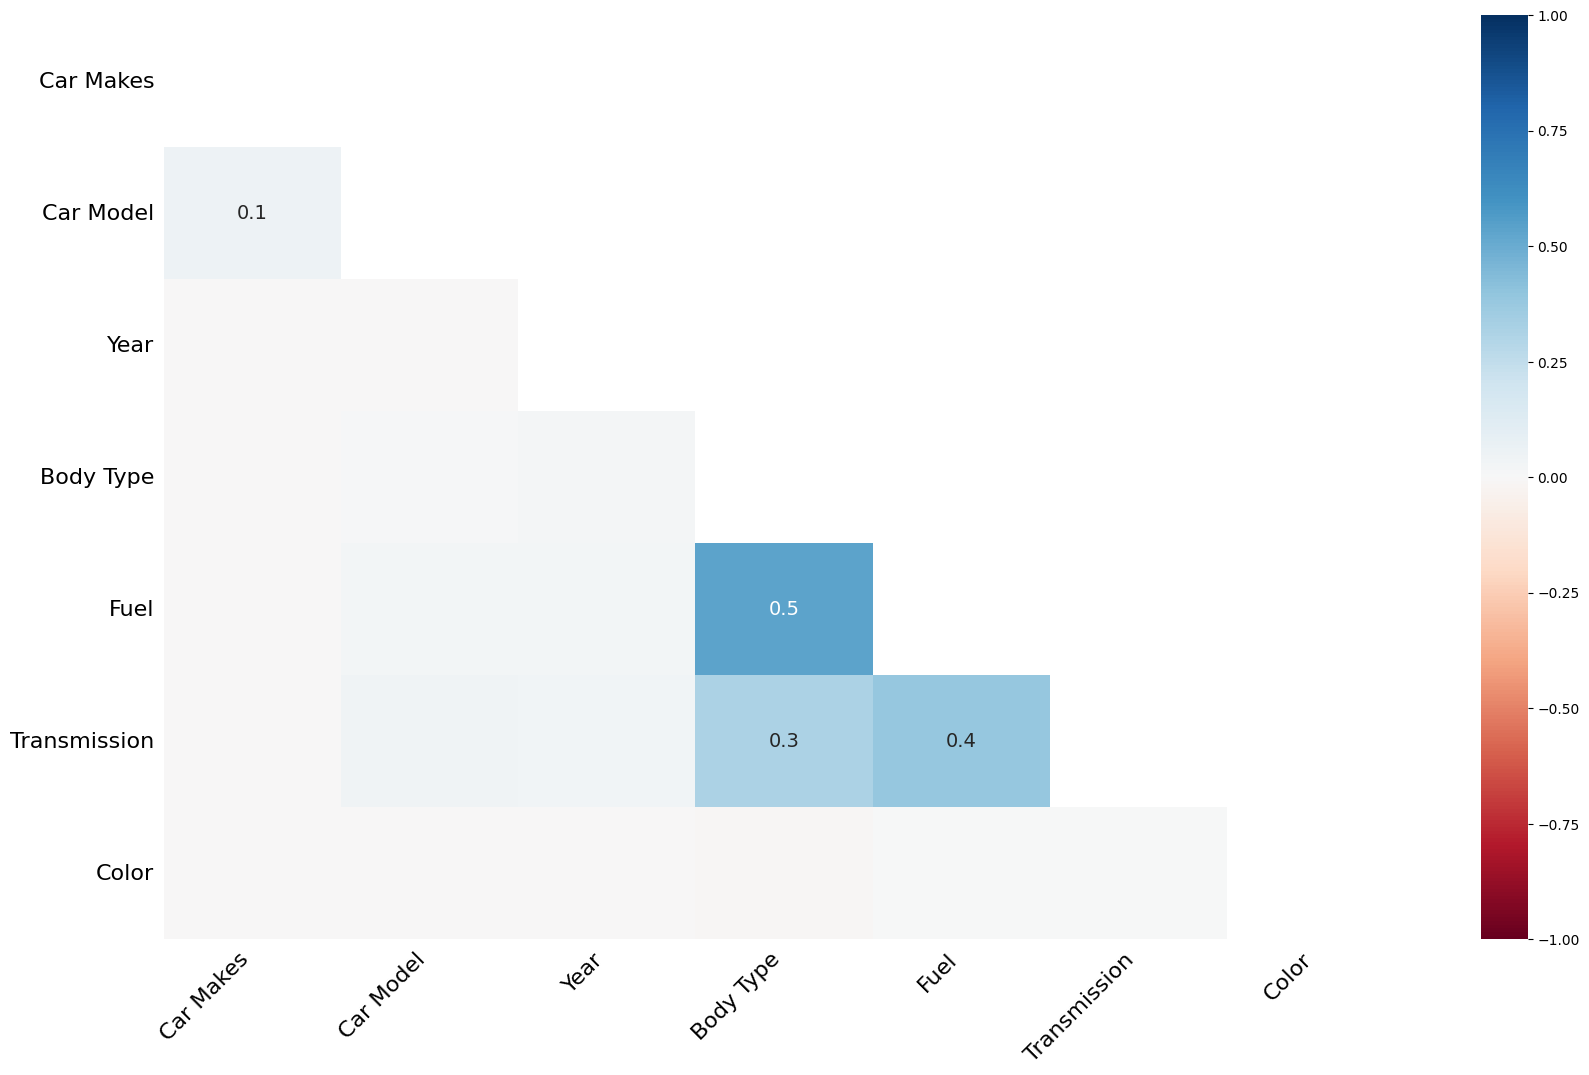

In [281]:
msno.heatmap(cars)

#### Listwise Deletion/ Droping rows 

In [282]:
# Remove 'None missing' from the feature list
feature_has_missing_values = [feature for feature in feature_has_missing_values if feature != 'None missing']

# Drop rows with missing values in the specified features
df = cars.dropna(subset=feature_has_missing_values, how='any')

# Check the remaining missing values
df.isnull().sum()


Ad ID           0
Category        0
Locations       0
Posted          0
Car Makes       0
Car Model       0
Year            0
Tax Type        0
Condition       0
Body Type       0
Fuel            0
Transmission    0
Color           0
Link            0
Title           0
Price           0
dtype: int64

In [283]:
cars.shape, df.shape

((17867, 16), (13037, 16))

### 3. Cleaning the 'Year' Feature 

In [284]:
df['Year'] = df['Year'].astype(int)

In [285]:
df.Year.dtype, df.shape

(dtype('int64'), (13037, 16))

---

### 4. Detect unkown values 

In [286]:
def check_column_value(df, value):
    """
    Checks if each column in a pandas DataFrame contains a specific value and prints the column names that contain the value.
    
    Parameters:
        df (pandas DataFrame): The DataFrame to check.
        value (any type): The value to look for in each column.
    """
    if type(value) != str:
        values = list(value)
    elif type(value) == list():
        values = value
    else: values = [value]
    matching_columns = df.apply(lambda col: col.isin(values).any())
    matching_columns = matching_columns[matching_columns == True]
    count = {}
    index = set()
    for value in values:
        for col in matching_columns.index.tolist():
            if count == {}:
                count[col] = []
            elif col not in count:
                count[col] = []
            
            count[col].append(df[df[col] == value].loc[:, col].count())
            for i in df[df[col] == value].loc[:, col].index.tolist():
                index.add(i)
  
    print(f"\033[94mColumns that contain the {values}:\n")
    print(pd.Series(count))
    
    return index
    

In [287]:
index = check_column_value(df, ['Other', 'Other - ផ្សេងៗ'])

Columns that contain the ['Other', 'Other - ផ្សេងៗ']:

Car Model     [0, 53]
Body Type    [920, 0]
Color        [274, 0]
dtype: object


In [288]:
df = df.drop(index, axis='rows')

In [289]:
df.shape

(11859, 16)

In [290]:
index_year = check_column_value(df, [2023, 2024])

Columns that contain the [2023, 2024]:

Year    [496, 70]
dtype: object


In [291]:
df = df.drop(index_year, axis = 'rows')

### 5. Correlation in numerical features 

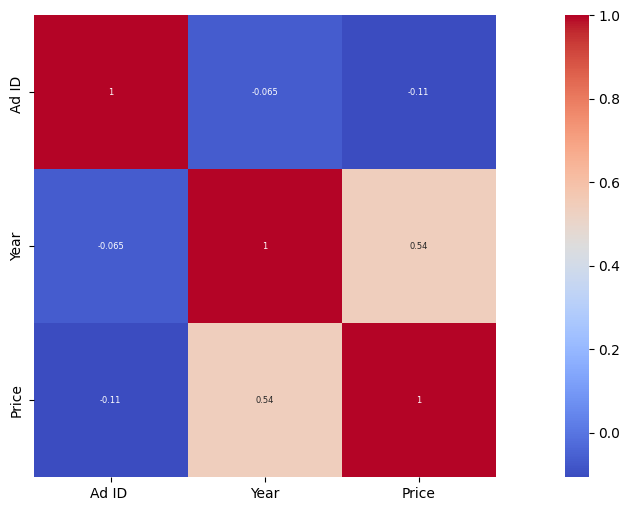

In [292]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation calculation
numeric_columns = cars.select_dtypes(include=['number']).columns

# Create the figure and axes objects
fig, ax = plt.subplots(figsize=(18,6))

# Create a heatmap for the correlation matrix of numeric columns
sns.heatmap(cars[numeric_columns].corr(), annot=True, square=True, ax=ax, cbar=True, annot_kws={"fontsize": 6}, cmap='coolwarm')

# Show the plot
plt.show()


---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:black;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
<a id ='4'><span>Exploratory Data Analysis (EDA)</span></a>
</p>
</div>

### 1. Visualizing our Target Feature. 

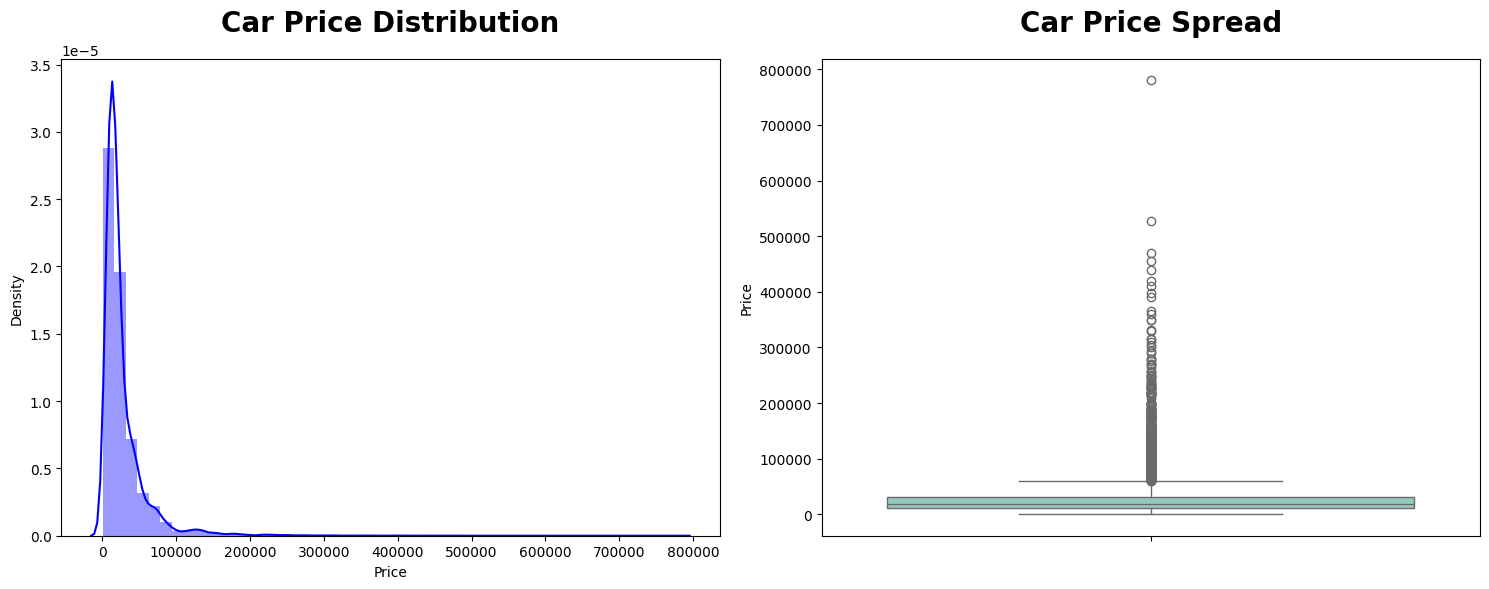

In [293]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize= (15, 6))
plt.subplot(1, 2, 1)
sns.distplot(df['Price'], color='blue', kde = True)
plt.title('Car Price Distribution', fontweight = 'black', pad = 20, fontsize = 20)

plt.subplot(1, 2, 2)
sns.boxplot(y = df['Price'], palette= 'Set3')
plt.title('Car Price Spread', fontweight = 'black', pad = 20, fontsize = 20)
plt.tight_layout()
plt.show()

In [294]:
df['Price'].agg(['min', 'mean', 'median','max','std', 'skew']).to_frame().T

,min,mean,median,max,std,skew
Price,500.0000,27336.7469,17800.0000,780000.0000,33006.6647,5.5204


#### Insights
1. We can clearly observe that our **Car Price Feature** is hiighly right skew and can be problematic for some machine learning algorithms, as they can lead to **biased models** and inaccurate predictions.
2. We can clearly observe there is a significant difference between **mean** & **median values**.
3. We can also that the **skewness of the car price is above 1.5** which mean that the data point are **highly spreed.**

---

### 2. Visualizing Total No. of cars sold by different company. 

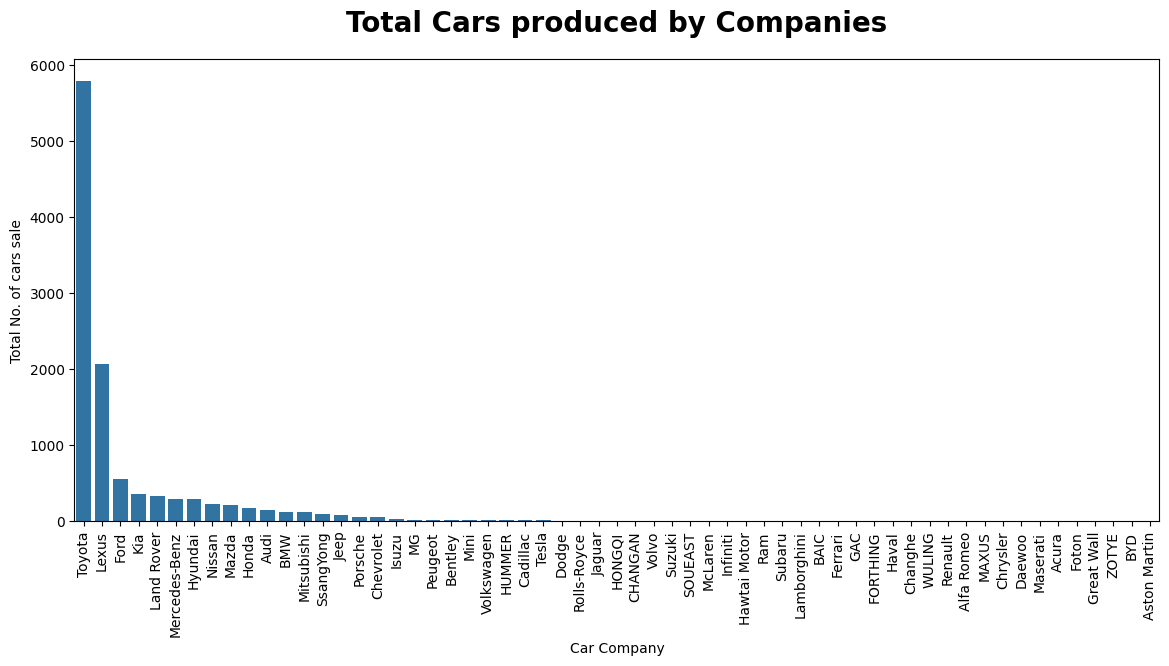

In [295]:
plt.figure(figsize = (14, 6))
counts = df['Car Makes'].value_counts()
sns.barplot(x = counts.index, y = counts.values)
plt.xlabel('Car Company')
plt.ylabel('Total No. of cars sale')
plt.title('Total Cars produced by Companies', pad = 20, fontweight = 'black', fontsize = 20 )
plt.xticks(rotation = 90)
plt.show()

In [296]:
df_brand = pd.DataFrame(df['Car Makes'].value_counts())
df_brand.describe()

,count
count,59.0000
mean,191.4068
std,793.1521
min,1.0000
25%,2.0000
50%,8.0000
75%,70.0000
max,5780.0000


In [297]:
df_brand['Car Makes'] = df_brand['count']

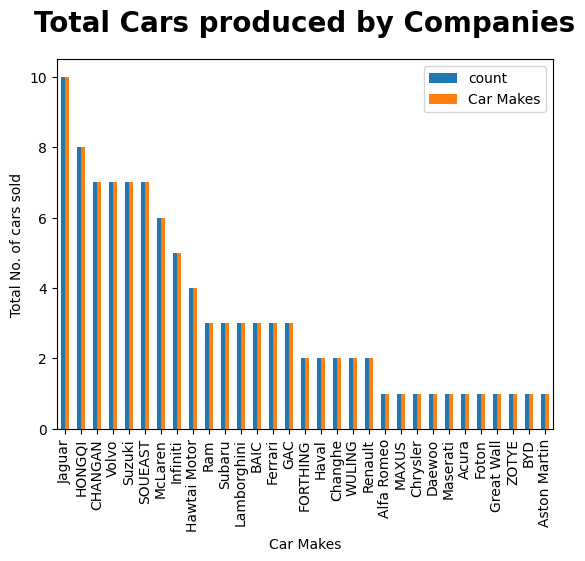

In [298]:
df_brand[df_brand['Car Makes']<= 10].plot(kind = 'bar')
plt.ylabel('Total No. of cars sold')
plt.title('Total Cars produced by Companies', pad = 20, fontweight = 'black', fontsize = 20 )
plt.show()

In [299]:
df[df['Car Makes'] == 'Aston Martin']

,Ad ID,Category,Locations,Posted,Car Makes,Car Model,Year,Tax Type,Condition,Body Type,Fuel,Transmission,Color,Link,Title,Price
13964,9415963,Cars for Sale,Phnom Penh,30-May-23,Aston Martin,Rapide,2011,Plate Number,Used,Sedan,Petrol,Auto,Silver,https://www.khmer24.com/en/cars/aston-martin-r...,Aston Martin Rapide 2011,130000.0000


In [300]:
df[df['Car Makes'] == 'BYD']

,Ad ID,Category,Locations,Posted,Car Makes,Car Model,Year,Tax Type,Condition,Body Type,Fuel,Transmission,Color,Link,Title,Price
13460,9504136,Cars for Sale,Phnom Penh,01-Jun-23,BYD,E2,2022,Plate Number,Used,Sedan,Electric,Auto,White,https://www.khmer24.com/en/cars/%E1%9E%A1%E1%9...,ឡានលក់,24500.0000


In [301]:
df[df['Car Makes'] == 'Acura']

,Ad ID,Category,Locations,Posted,Car Makes,Car Model,Year,Tax Type,Condition,Body Type,Fuel,Transmission,Color,Link,Title,Price
12130,9519592,Cars for Sale,Phnom Penh,04-Jun-23,Acura,MDX,2017,Plate Number,Used,SUV,Petrol,Auto,Black,https://www.khmer24.com/en/cars/acura%E1%9E%80...,Acura(ក្រុមហ៊ុន Honda នៅអាមេរិក)​ MDX 2017,88000.0000


In [302]:
df[(df['Car Makes'] == 'ZOTYE') | (df['Car Makes'] == 'Acura')]

,Ad ID,Category,Locations,Posted,Car Makes,Car Model,Year,Tax Type,Condition,Body Type,Fuel,Transmission,Color,Link,Title,Price
12130,9519592,Cars for Sale,Phnom Penh,04-Jun-23,Acura,MDX,2017,Plate Number,Used,SUV,Petrol,Auto,Black,https://www.khmer24.com/en/cars/acura%E1%9E%80...,Acura(ក្រុមហ៊ុន Honda នៅអាមេរិក)​ MDX 2017,88000.0000
12965,9266267,Cars for Sale,Phnom Penh,02-Jun-23,ZOTYE,T800,2020,Plate Number,New,SUV,Petrol,Auto,Black,https://www.khmer24.com/en/cars/selling-car-ad...,Selling Car,45500.0000


In [303]:
df[(df['Car Makes'] == 'ZOTYE') | (df['Car Makes'] == 'Acura')]

,Ad ID,Category,Locations,Posted,Car Makes,Car Model,Year,Tax Type,Condition,Body Type,Fuel,Transmission,Color,Link,Title,Price
12130,9519592,Cars for Sale,Phnom Penh,04-Jun-23,Acura,MDX,2017,Plate Number,Used,SUV,Petrol,Auto,Black,https://www.khmer24.com/en/cars/acura%E1%9E%80...,Acura(ក្រុមហ៊ុន Honda នៅអាមេរិក)​ MDX 2017,88000.0000
12965,9266267,Cars for Sale,Phnom Penh,02-Jun-23,ZOTYE,T800,2020,Plate Number,New,SUV,Petrol,Auto,Black,https://www.khmer24.com/en/cars/selling-car-ad...,Selling Car,45500.0000


In [304]:
df[df['Car Makes'].isin(df_brand[df_brand['Car Makes'] <=1].index)]

,Ad ID,Category,Locations,Posted,Car Makes,Car Model,Year,Tax Type,Condition,Body Type,Fuel,Transmission,Color,Link,Title,Price
4972,9534548,Cars for Sale,Phnom Penh,10-Jun-23,MAXUS,G50,2021,Plate Number,New,MPV (Minivan),Petrol,Auto,White,https://www.khmer24.com/en/cars/maxus-g50-2021...,Maxus G50 2021,27900.0000
6019,9534542,Cars for Sale,Phnom Penh,10-Jun-23,Chrysler,300C,2007,Plate Number,Used,Sedan,Petrol,Auto,Black,https://www.khmer24.com/en/cars/%E1%9E%81%E1%9...,ខ្ញុំបាទចង់លក់ឡានមួយគ្រឿង crysler 2007 V6 ខ្លា...,13500.0000
6774,9491467,Cars for Sale,Phnom Penh,09-Jun-23,Alfa Romeo,Giulia,2015,Plate Number,Used,Sports,Petrol,Auto,Black,https://www.khmer24.com/en/cars/chineses-car-f...,Chinese’s car for sale in best price,48000.0000
10021,8943294,Cars for Sale,Kandal,07-Jun-23,Daewoo,Lanos,1999,Plate Number,Used,MPV (Minivan),LPG,Manual,White,https://www.khmer24.com/en/cars/%E1%9E%A1%E1%9...,ឡានតូរីសតូច សម្រាប់ប្រកបអាជីវកម្មបាន កែហើយលក់ធ...,2100.0000
11655,9523556,Cars for Sale,Phnom Penh,05-Jun-23,Maserati,Levante,2022,Tax Paper,New,SUV,Hybrid,Auto,Blue,https://www.khmer24.com/en/cars/%E1%9E%9A%E1%9...,រថយន្តអ៉ីតាលីសម្រាប់លក់,178000.0000
12130,9519592,Cars for Sale,Phnom Penh,04-Jun-23,Acura,MDX,2017,Plate Number,Used,SUV,Petrol,Auto,Black,https://www.khmer24.com/en/cars/acura%E1%9E%80...,Acura(ក្រុមហ៊ុន Honda នៅអាមេរិក)​ MDX 2017,88000.0000
12551,9515599,Cars for Sale,Phnom Penh,03-Jun-23,Foton,CS2,2021,Plate Number,New,MPV (Minivan),Diesel,Manual,White,https://www.khmer24.com/en/cars/%E1%9E%91%E1%9...,ទ្បានលក់បន្ទាន់,38800.0000
12584,8941862,Cars for Sale,Siem Reap,03-Jun-23,Great Wall,Poer-1,2016,Plate Number,New,SUV,Diesel,Manual,White,https://www.khmer24.com/en/cars/great-wall-201...,Great Wall 2016 m4 32000km,9500.0000
12965,9266267,Cars for Sale,Phnom Penh,02-Jun-23,ZOTYE,T800,2020,Plate Number,New,SUV,Petrol,Auto,Black,https://www.khmer24.com/en/cars/selling-car-ad...,Selling Car,45500.0000
13460,9504136,Cars for Sale,Phnom Penh,01-Jun-23,BYD,E2,2022,Plate Number,Used,Sedan,Electric,Auto,White,https://www.khmer24.com/en/cars/%E1%9E%A1%E1%9...,ឡានលក់,24500.0000


#### Insights
1. **Toyota** company has sale the highest number of cars.
2. So we can say that **Toyota** is kind of customers most favoured campany.
3. **MAXUS, Chrysler, Alfa Romeo, Acura, ZOTYE, BYD, and Aston Martin** are having very low data-points. So we can't make any inference of least salse car companies.

---

### 3. Visualizing Car Company with Price. 

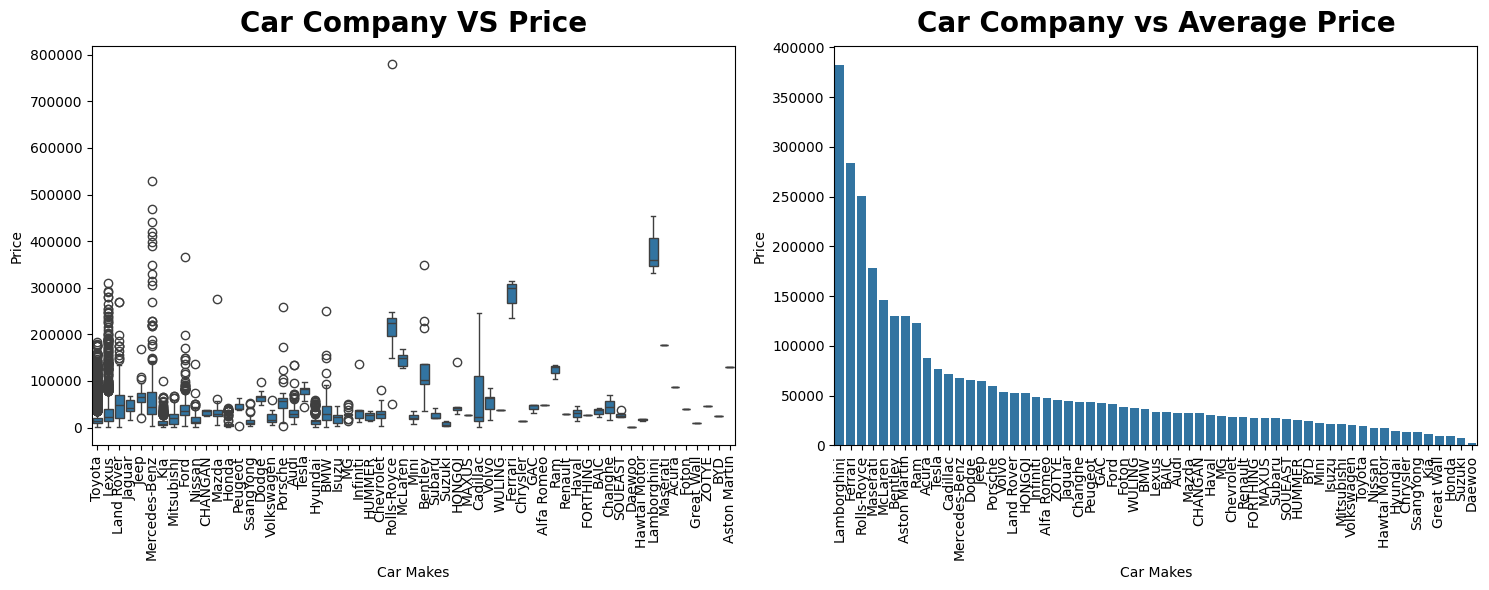

In [305]:
plt.figure(figsize = (15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x = 'Car Makes', y = 'Price', data = df)
plt.xticks(rotation = 90)
plt.title('Car Company VS Price', pad = 10, fontweight = 'black', fontsize = 20)

plt.subplot(1, 2, 2)
x = pd.DataFrame(df.groupby('Car Makes')['Price'].mean().sort_values(ascending = False))
sns.barplot(x = x.index, y = 'Price', data = x)
plt.xticks(rotation = 90)
plt.title("Car Company vs Average Price", pad=10, fontweight="black", fontsize=20)
plt.tight_layout()
plt.show()

In [306]:
df[df['Car Makes'].isin(x[x['Price']< 10482.2237].index)].sort_values('Price', ascending = False)

,Ad ID,Category,Locations,Posted,Car Makes,Car Model,Year,Tax Type,Condition,Body Type,Fuel,Transmission,Color,Link,Title,Price
5274,9386051,Cars for Sale,Phnom Penh,10-Jun-23,Honda,CR-V,2022,Plate Number,Used,SUV,Petrol,Auto,White,https://www.khmer24.com/en/cars/crv-adid-93860...,CRV,42000.0000
5682,9378656,Cars for Sale,Phnom Penh,10-Jun-23,Honda,CR-V,2021,Plate Number,Used,SUV,Petrol,Auto,White,https://www.khmer24.com/en/cars/%E1%9E%A1%E1%9...,ឡានថ្មីខ្លាំង​ ម្ចាស់ទិញថ្មីខ្លាញ់គោ,39500.0000
8439,9097641,Cars for Sale,Phnom Penh,09-Jun-23,Honda,CR-V,2020,Plate Number,Used,MPV (Minivan),Petrol,Auto,White,https://www.khmer24.com/en/cars/%E1%9E%9B%E1%9...,លក់បន្ទាន់,39500.0000
12446,9278460,Cars for Sale,Phnom Penh,04-Jun-23,Honda,CR-V,2020,Plate Number,Used,SUV,Diesel,Auto,White,https://www.khmer24.com/en/cars/%E1%9E%9B%E1%9...,លក់បន្ទាន់,38500.0000
574,9539236,Cars for Sale,Phnom Penh,10-Jun-23,Honda,CR-V,2020,Plate Number,Used,SUV,Petrol,Auto,White,https://www.khmer24.com/en/cars/honda-crv-2020...,#Honda CRV 2020​ ម្ចាស់ដេីម,38000.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3424,9545231,Cars for Sale,Kampong Thom,10-Jun-23,Honda,CR-V,1997,Plate Number,Used,SUV,Petrol,Auto,Green,https://www.khmer24.com/en/cars/%E1%9E%85%E1%9...,ចងលក់CRV1997,2500.0000
16542,9445210,Cars for Sale,Stung Treng,19-May-23,Honda,CR-V,1997,Plate Number,Used,SUV,Petrol,Auto,Black,https://www.khmer24.com/en/cars/%E1%9E%A1%E1%9...,ឡានលក់បន្ទាន់,2500.0000
6871,9482156,Cars for Sale,Phnom Penh,09-Jun-23,Honda,Civic,1998,Plate Number,Used,Hatchback,Petrol,Auto,Black,https://www.khmer24.com/en/cars/%E1%9E%A1%E1%9...,ឡានម៉ាកហុងដាលក់ក្នុងតម្លៃ2500$ចរចាទឡាននៅស្អាត,2500.0000
10021,8943294,Cars for Sale,Kandal,07-Jun-23,Daewoo,Lanos,1999,Plate Number,Used,MPV (Minivan),LPG,Manual,White,https://www.khmer24.com/en/cars/%E1%9E%A1%E1%9...,ឡានតូរីសតូច សម្រាប់ប្រកបអាជីវកម្មបាន កែហើយលក់ធ...,2100.0000


#### Insights
1. **Lamborghini, Farrari, and Rolls-Royce** seems to have price range cars.
2. Car campanies like **Daewoo** & **Suzuki** are having a little bit in our dataset.
3. So we can't make any inference related to lowest price range car companies.

#### Note
- Sine there are too many categories in car company feature. So we can derive a new feature **Campany Price Range** which will show the price range as **Low Range, Medium Range, Hight Range**.

---

### 4. Visualizing Car Fuel Type Feature 

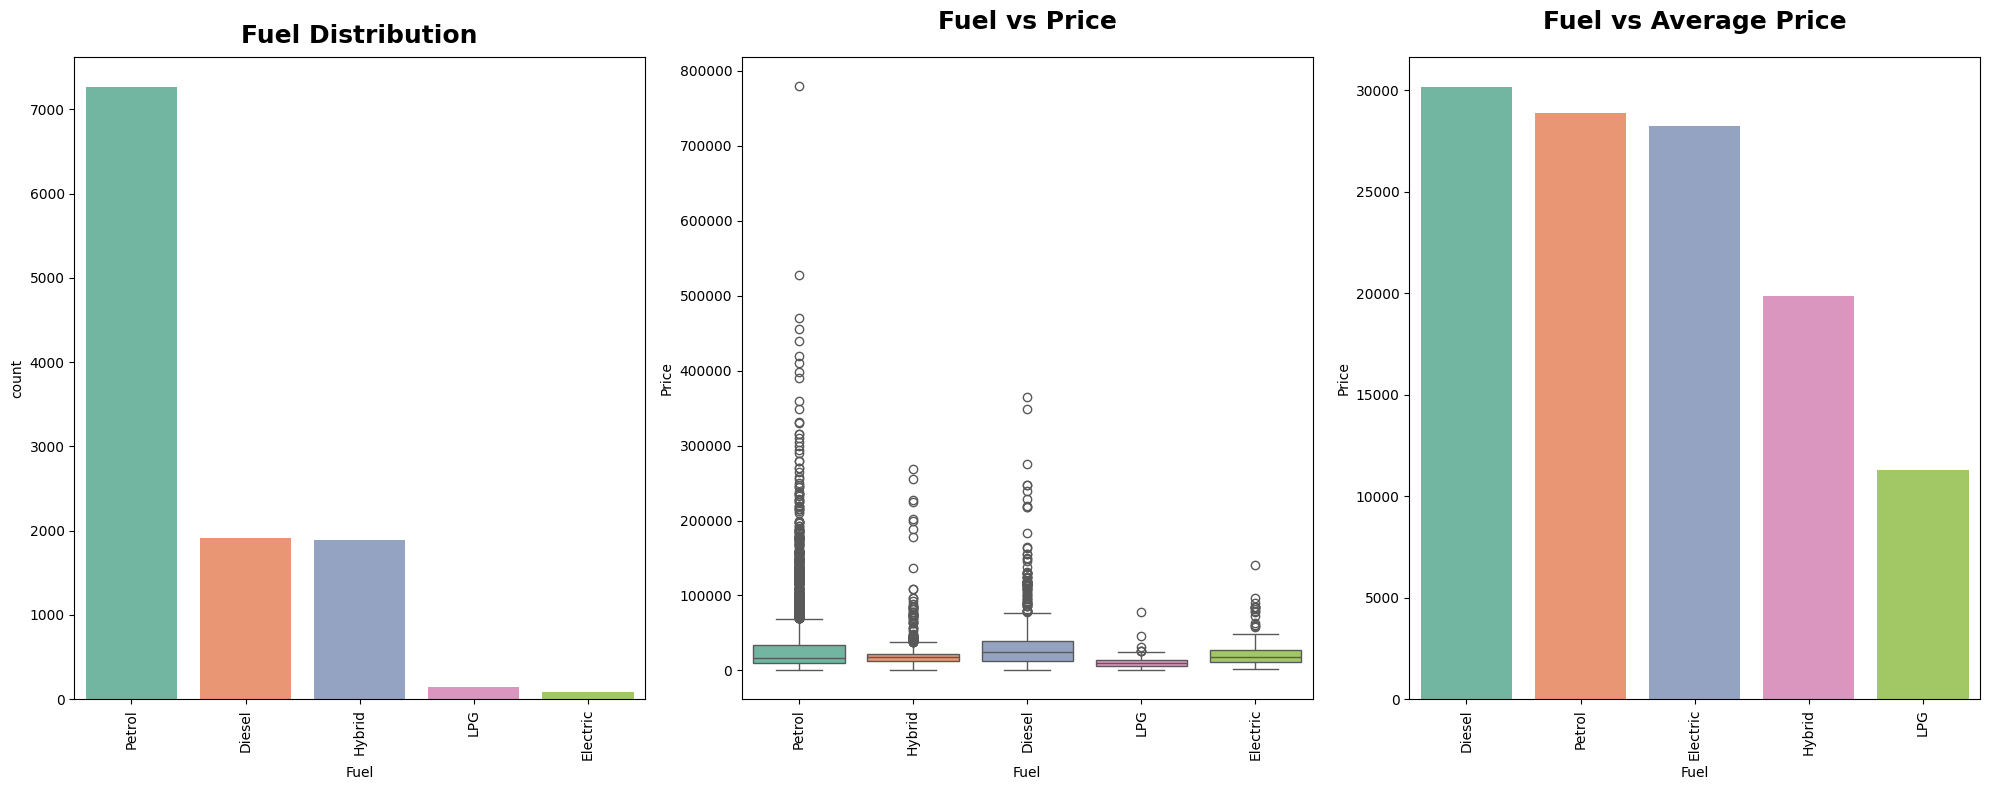

In [307]:
def categorical_visualization(cols):
    plt.figure(figsize=(20,8))
    plt.subplot(1,3,1)
    sns.countplot(x=cols,data=df,palette="Set2",order=df[cols].value_counts().index)
    plt.title(f"{cols} Distribution",pad=10,fontweight="black",fontsize=18)
    plt.xticks(rotation=90)

    plt.subplot(1,3,2)
    sns.boxplot(x=cols,y="Price",data=df,palette="Set2")
    plt.title(f"{cols} vs Price",pad=20,fontweight="black",fontsize=18)
    plt.xticks(rotation=90)
    
    plt.subplot(1,3,3)
    x=pd.DataFrame(df.groupby(cols)["Price"].mean().sort_values(ascending=False))
    sns.barplot(x=x.index,y="Price",data=x,palette="Set2")
    plt.title(f"{cols} vs Average Price",pad=20,fontweight="black",fontsize=18)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

categorical_visualization("Fuel")

#### Insights
1. We can clearly make an insight that **Cars having petrol fuel systme** is mostly sold.
2. From the second plot we can make insight that **Petrol Fuel System cars** are availabe within every **price range**.
3. From the third plot we can make an insight the **Average price of petrol fuel type cars are less than diesl fuel type cars**.

---

### 5. Visualizing Tax Type 

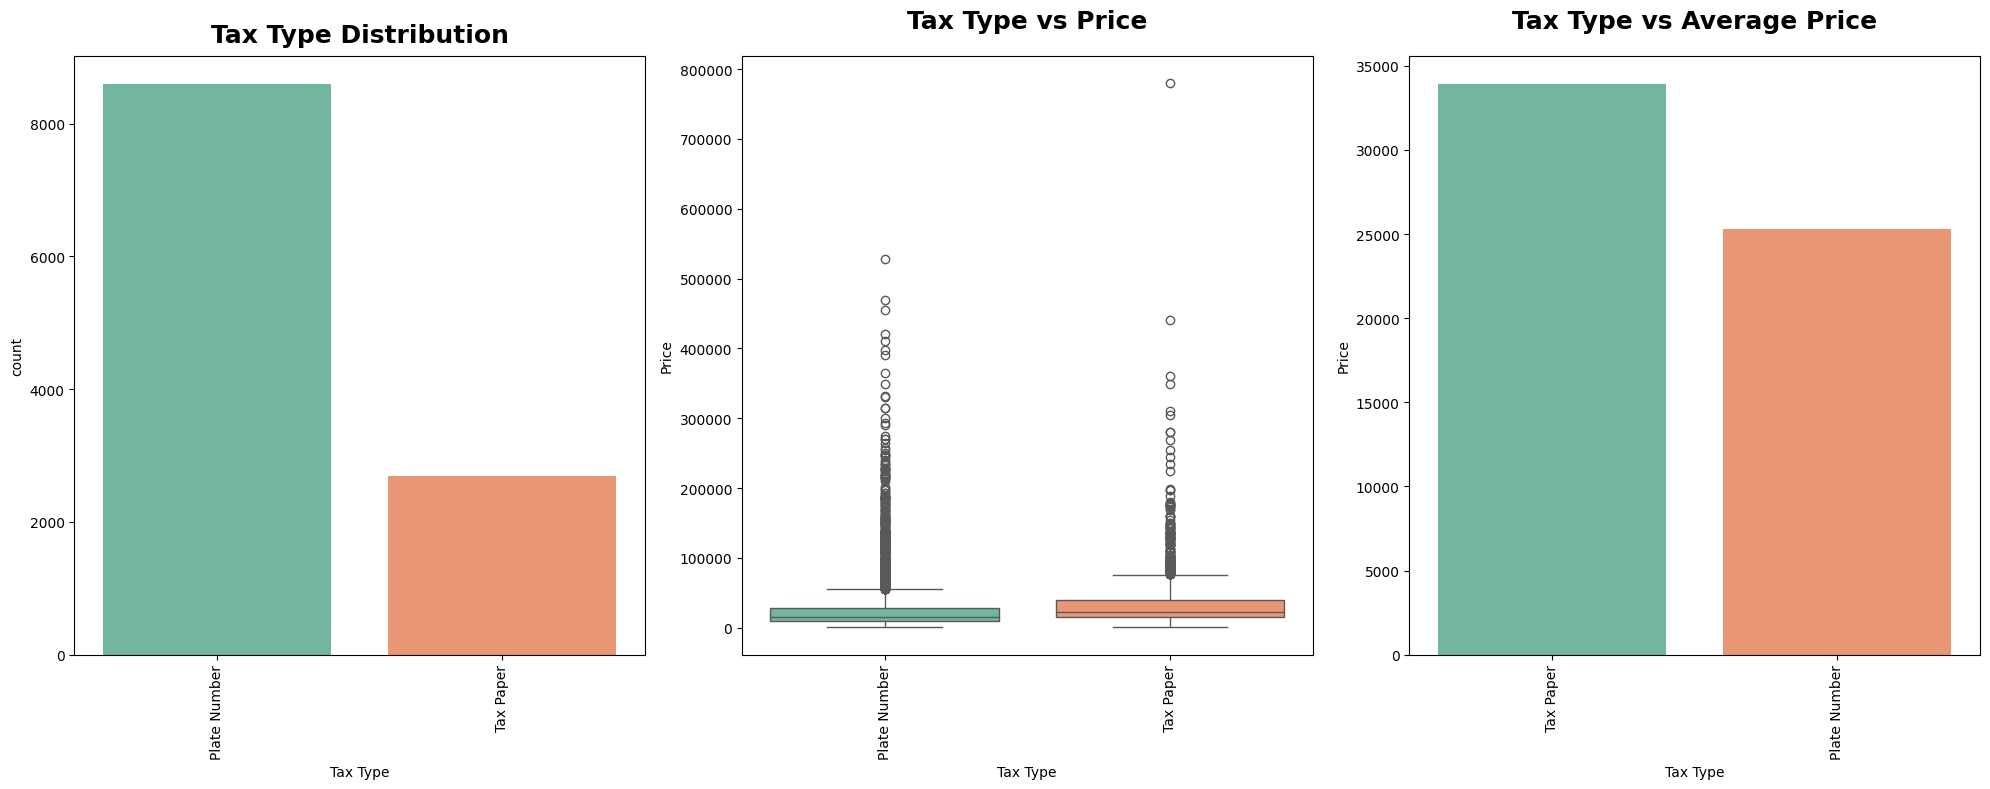

In [308]:
categorical_visualization('Tax Type')

#### Observation
1. Cars **Plate Number** are mostly sale when compared with cars **Tax Paper**.
2. Cars **Tax Paper** are more expansive than Cars **Plate Number**.

#### Insights
1. Outliers present in both.

---

### 6. Visualizing  Conditon Feature

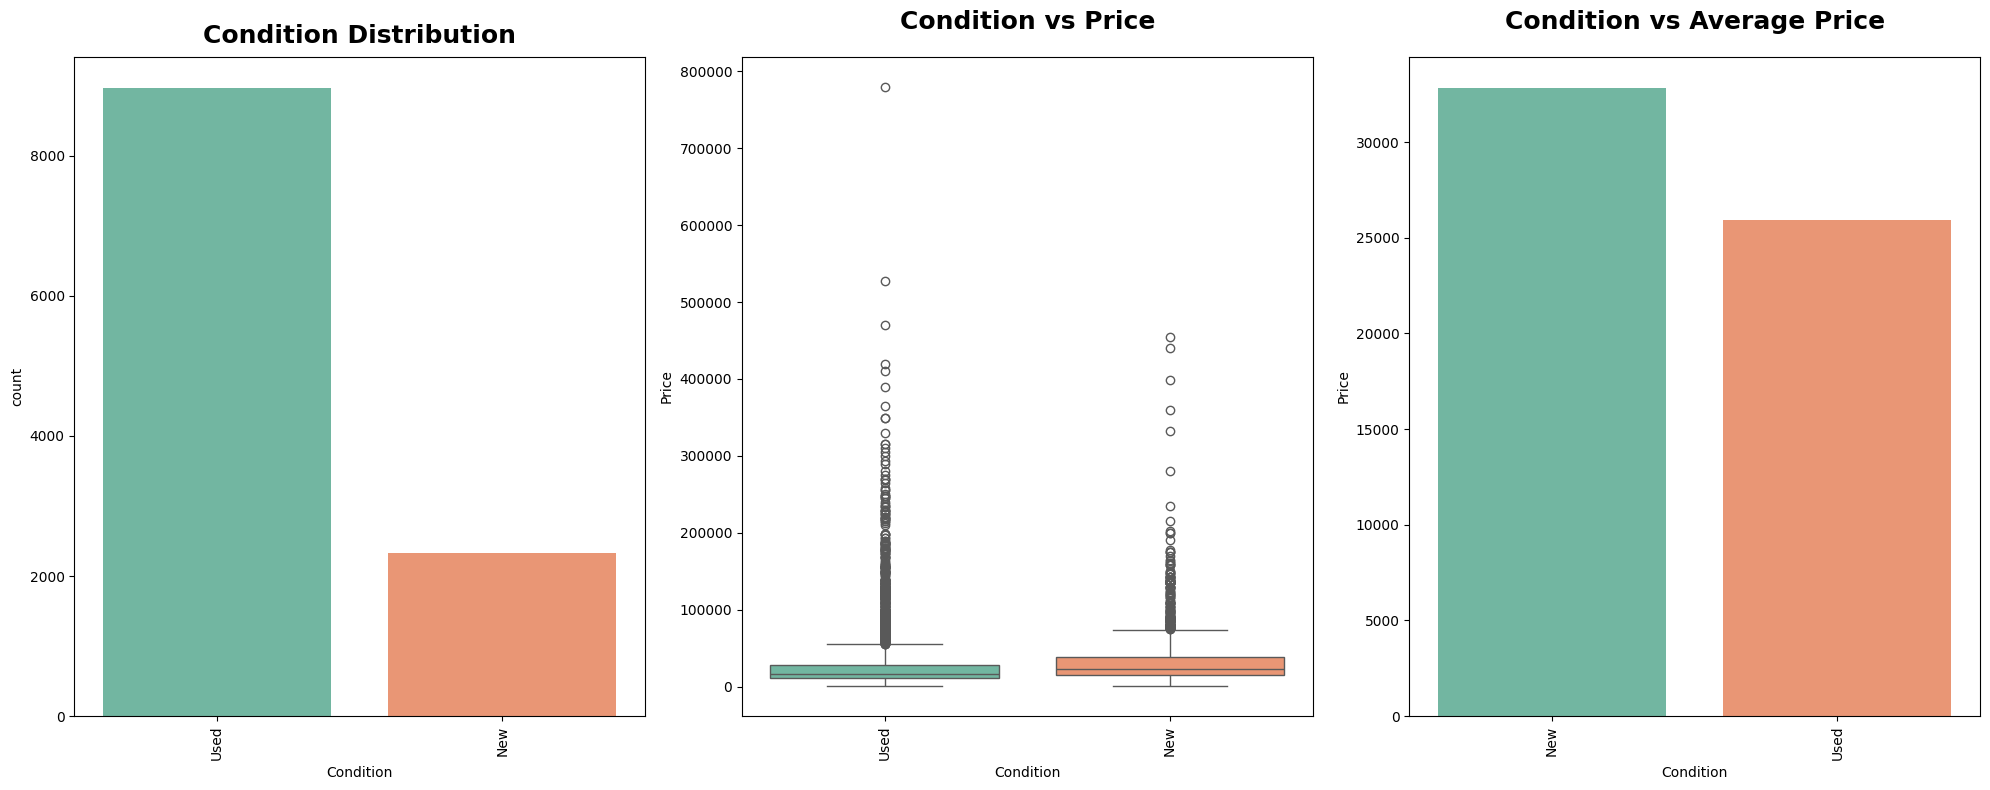

In [309]:
categorical_visualization('Condition')

#### Observation
1. The website has **cars used** more than **cars new**
2. **Cars New** are higher average price than **Car used**

---

### 7. Visualizing Body Type Feature

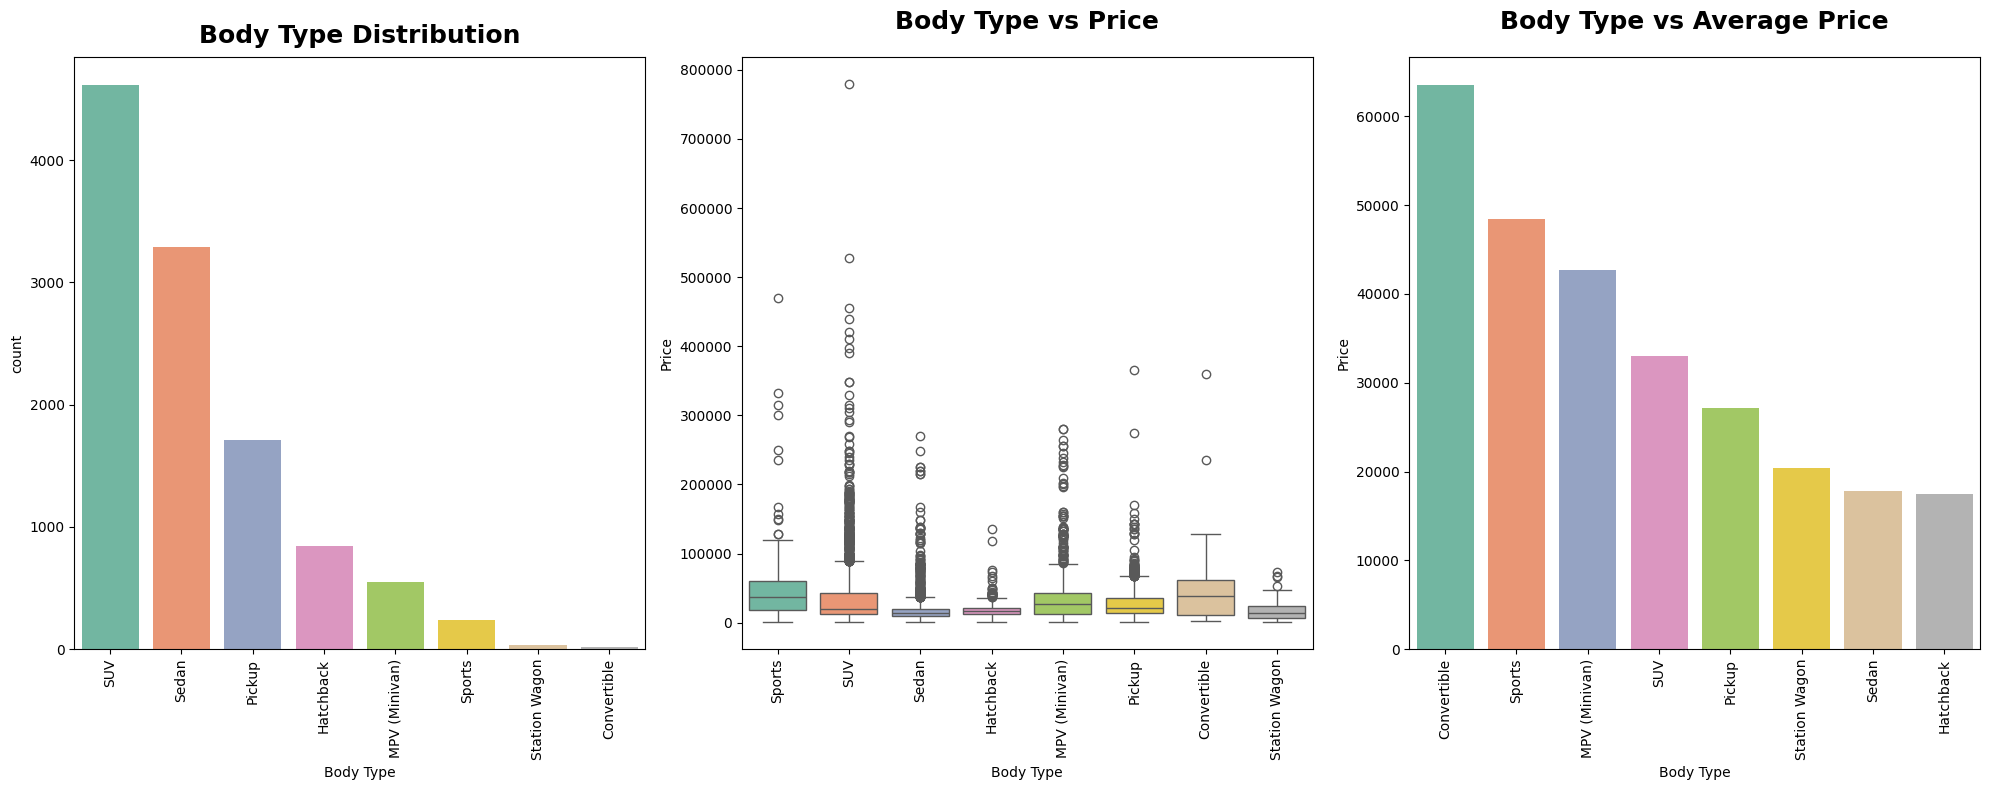

In [310]:
categorical_visualization('Body Type')

#### Obseration
1. Cars having **SUV** body-type are mostly salse followed by **Sedan**.
2. Cars having **converitble** or **hardtop** body-type are less salse.
3. Cars having **Converitble** body-type is the mostly expensive cars foolowed by **sport**.

#### Insights
1. **Convertible** & **Sport** body-type are less salse because they are very expensive cars. So most of the customers couldn't prefer it.
2. Car having **SUV** body-type is the fourth most expensive car. But still its having the most number of cars sales. So we can say customer prefer **medium price range cars**.

---

### 8. Visualizing Transmission Feature 

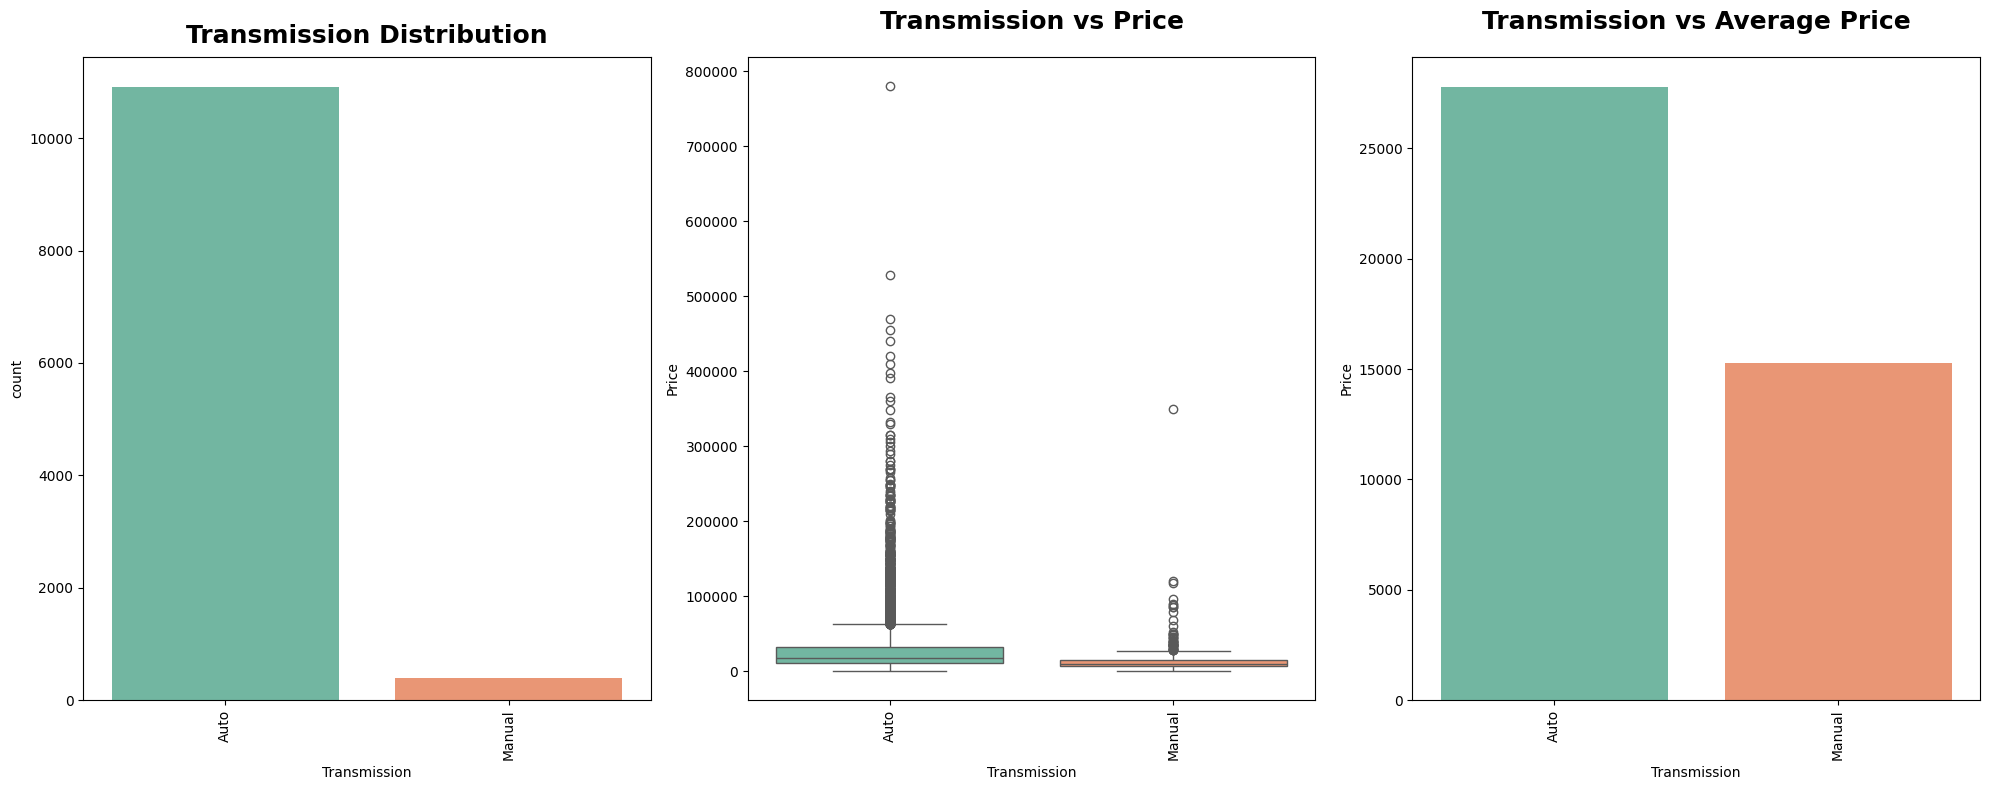

In [311]:
categorical_visualization('Transmission')

---

### 9. Visualizing Color Feature 

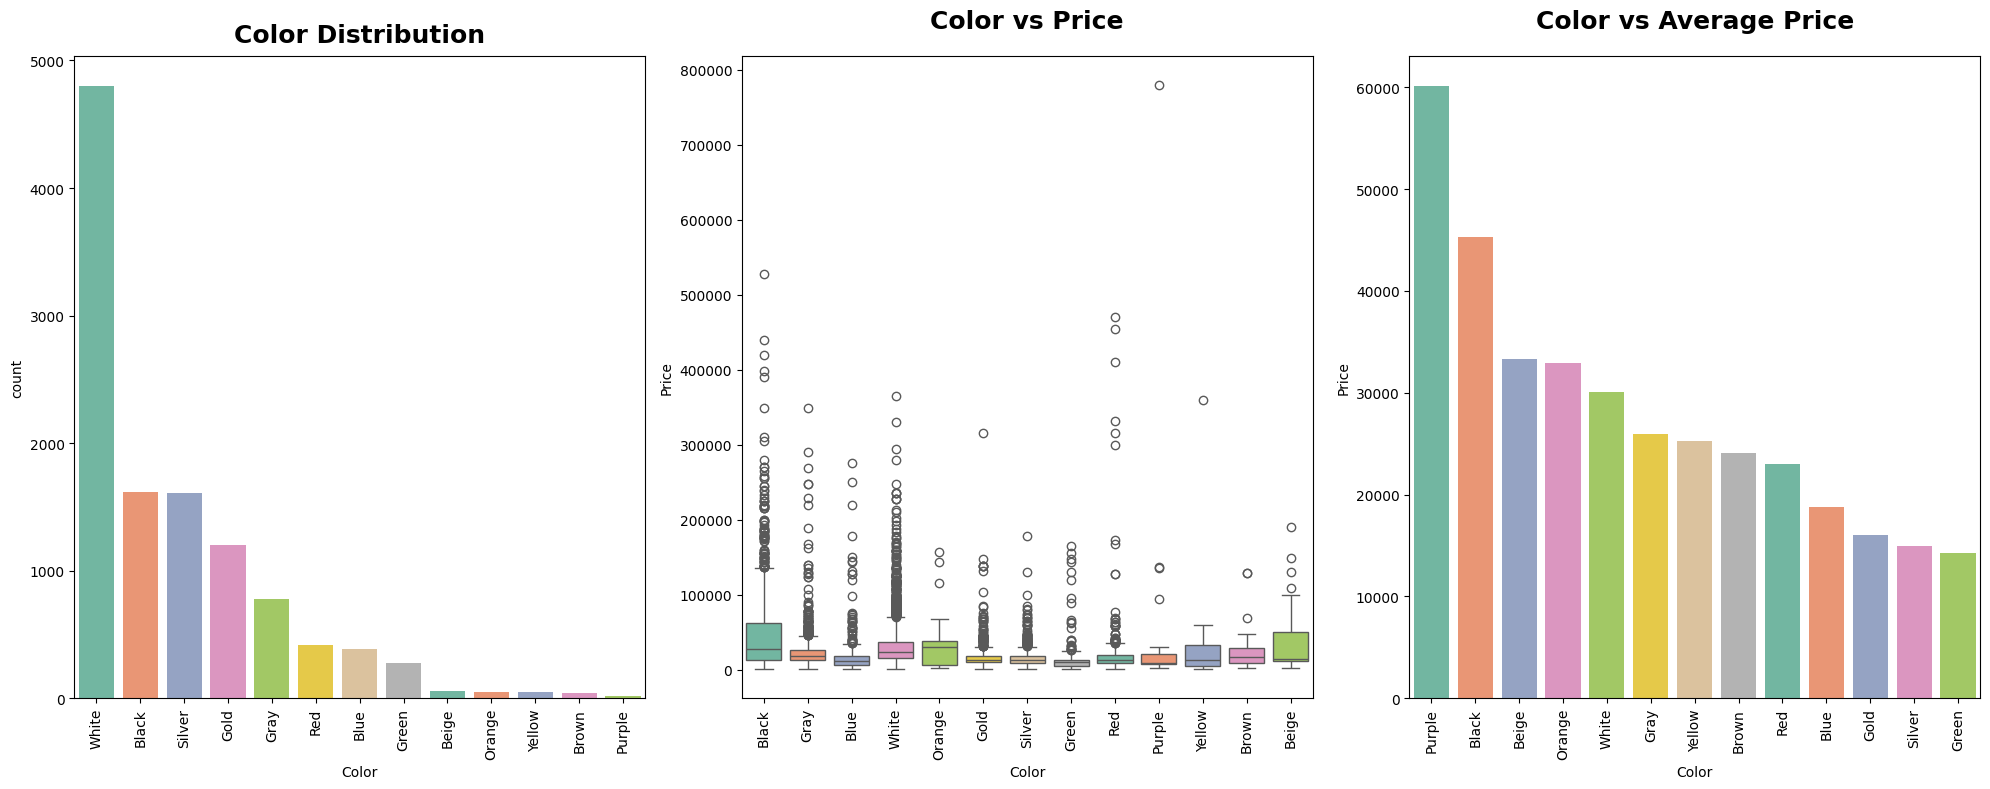

In [312]:
categorical_visualization('Color')

---

### 10. Visualizion Car Models Features 

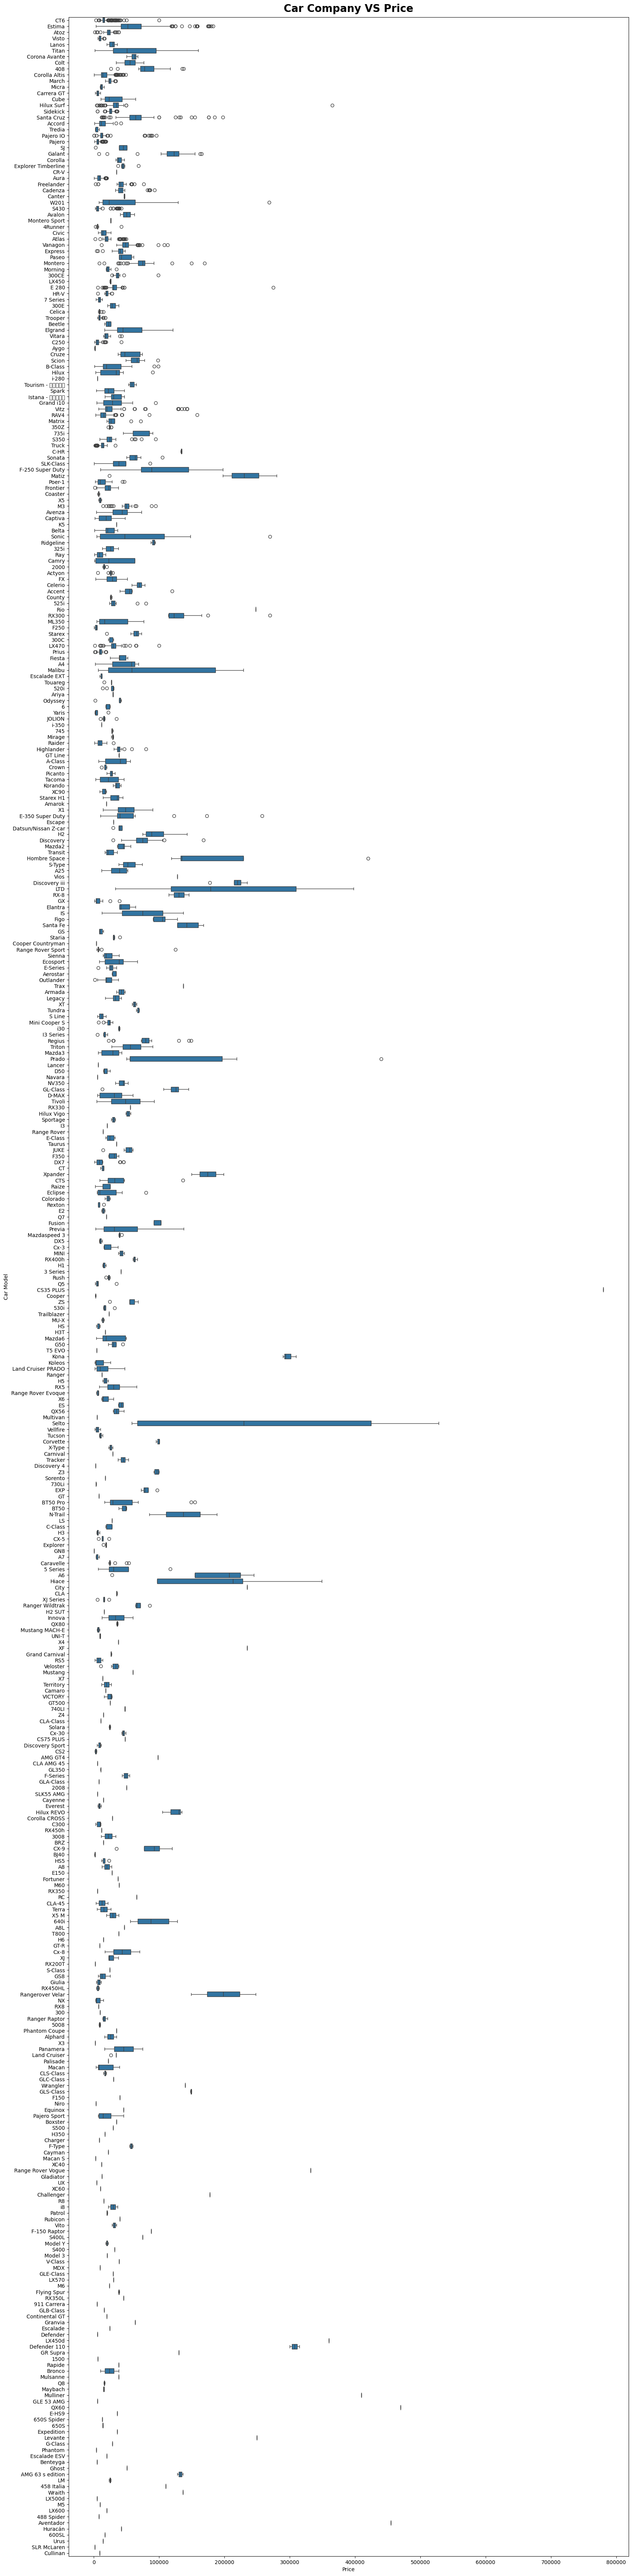

In [313]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot
fig, ax = plt.subplots(figsize=(20, 80))

# Create a horizontal boxplot
sns.boxplot(x='Price', y='Car Model', data=df, orient='h', ax=ax)

# Sort the categories by median price
medians = df.groupby(['Car Model'])['Price'].median().sort_values()
category_order = medians.index.tolist()
ax.set_yticklabels(category_order)

# Add labels and adjust margins
ax.set_xlabel('Price')
ax.set_ylabel('Car Model')
ax.set_title('Car Company VS Price', pad=10, fontweight='black', fontsize=20)
plt.subplots_adjust(left=0.2, right=0.95, top=0.95, bottom=0.1)

plt.show()

Text(0.5, 1.0, 'Car Company VS Price')

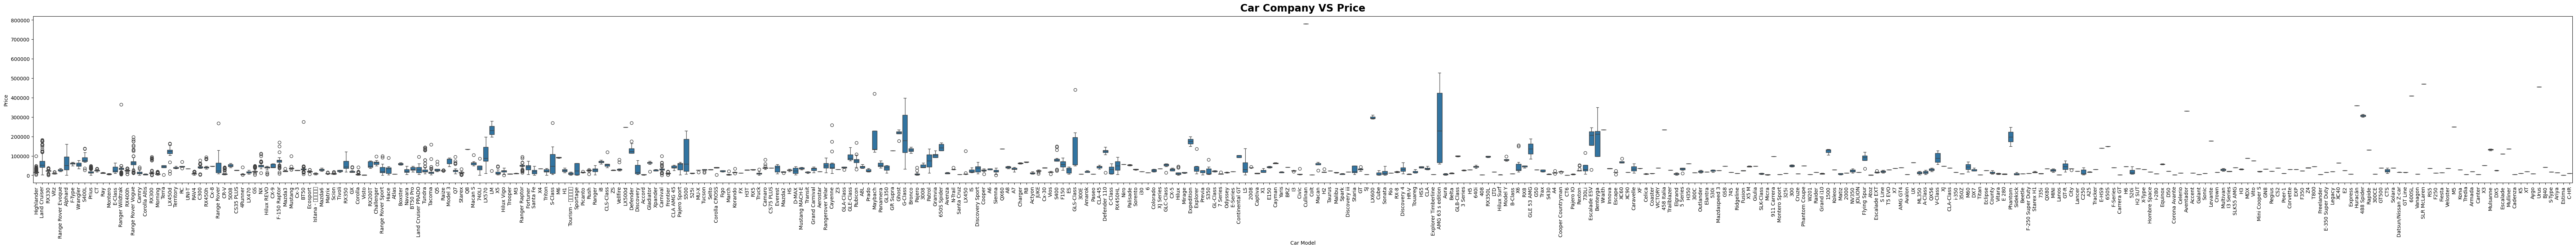

In [314]:
plt.figure(figsize = (200, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x = 'Car Model', y = 'Price', data = df, orient= 'v')
plt.xticks(rotation = 90)
plt.title('Car Company VS Price', pad = 10, fontweight = 'black', fontsize = 20)

In [315]:
# # Pivot the data to create a table of counts for each category
# table = df.pivot_table(index='Car Model', columns='Price', aggfunc='size')

# # Create a horizontal stacked barplot
# fig, ax = plt.subplots(figsize=(12, 8))
# table.plot(kind='barh', stacked=True, ax=ax)

# # Set the title and axis labels
# ax.set_title('Car Company VS Price')
# ax.set_xlabel('Count')
# ax.set_ylabel('Car Model')

# plt.show()

---

### 11. Visualizing Car Location Features 

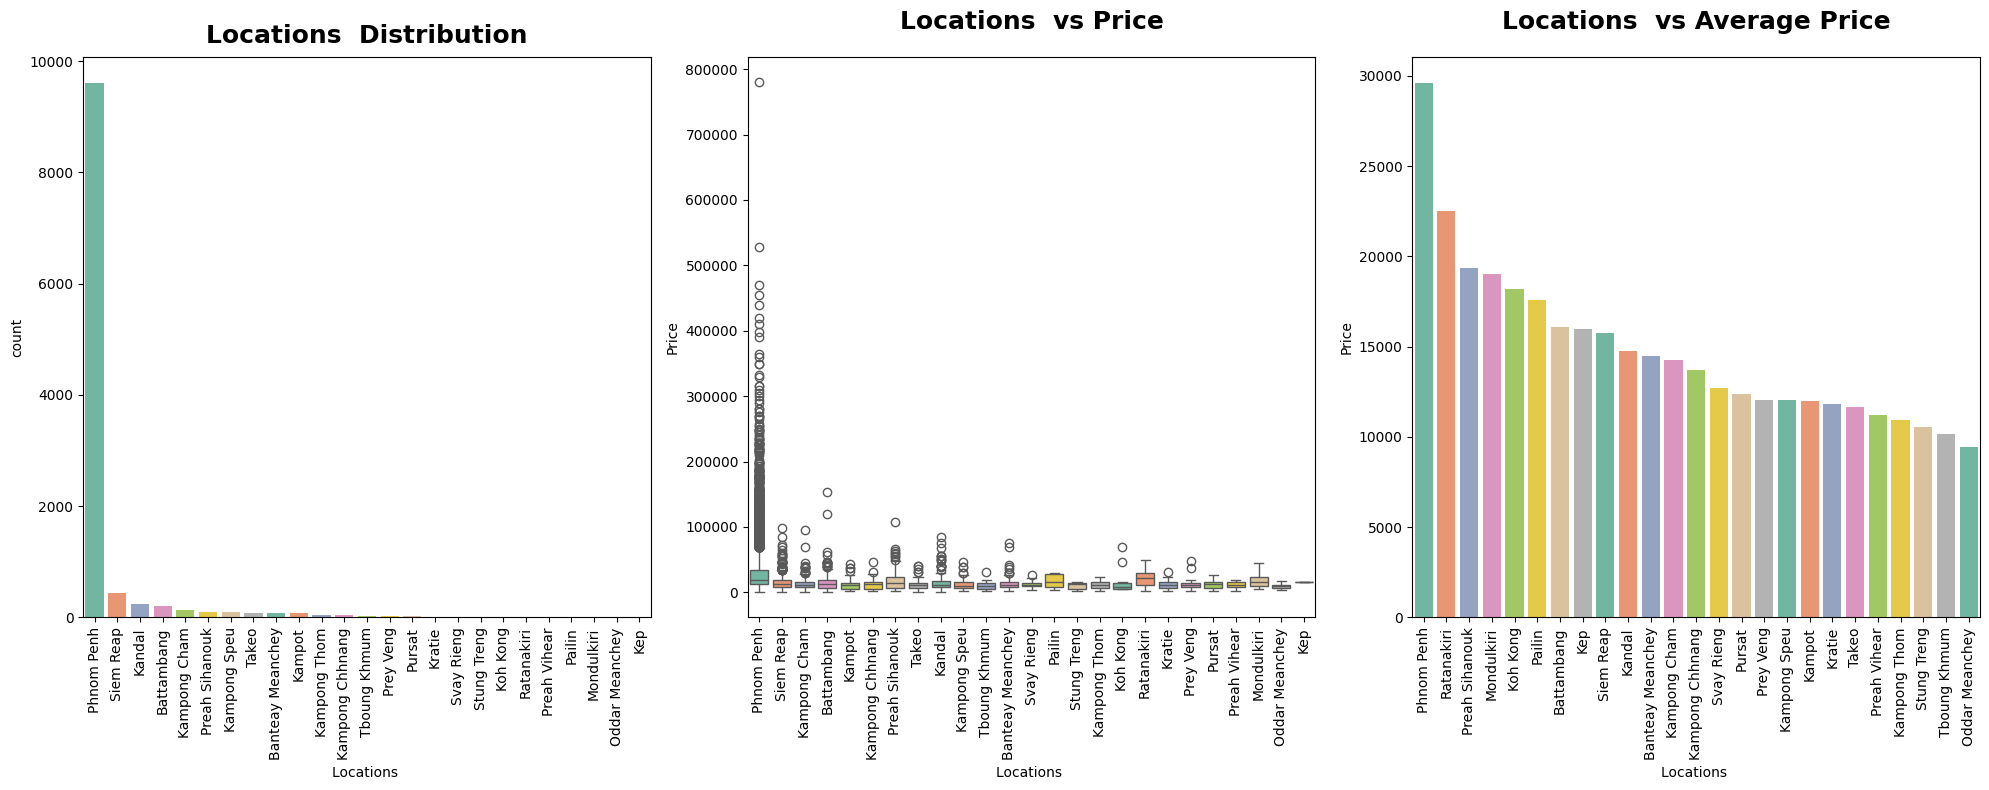

In [316]:
categorical_visualization('Locations ')

### 12. Visualizing Year Features. 

In [317]:
def scatter_plot(cols):
    x=1
    plt.figure(figsize=(15,6))
    for col in cols:
        plt.subplot(1,2,x)
        sns.scatterplot(x=col,y="Price",data=df,color="blue")
        plt.title(f"{col} vs Price",fontweight="black",fontsize=20,pad=10)
        plt.tight_layout()
        x+=1

In [318]:
df_numerical.columns

Index(['Ad ID ', 'Year'], dtype='object')

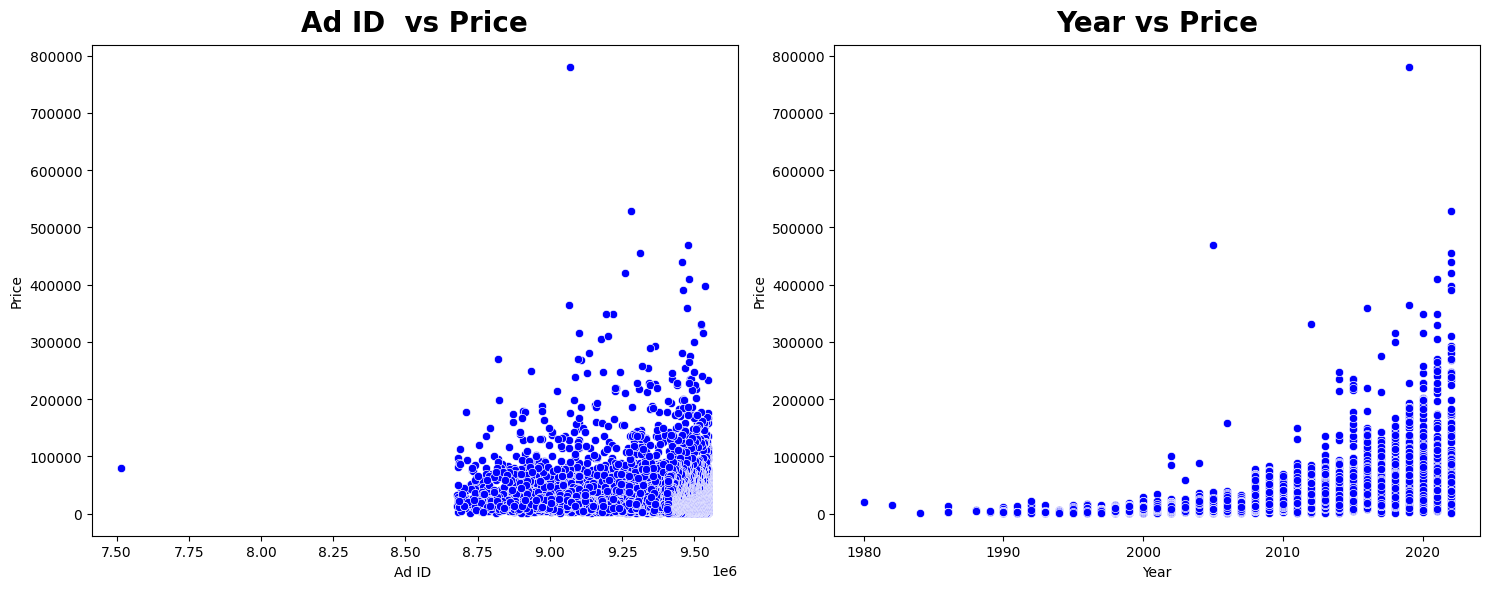

In [319]:
scatter_plot(['Ad ID ', 'Year'])

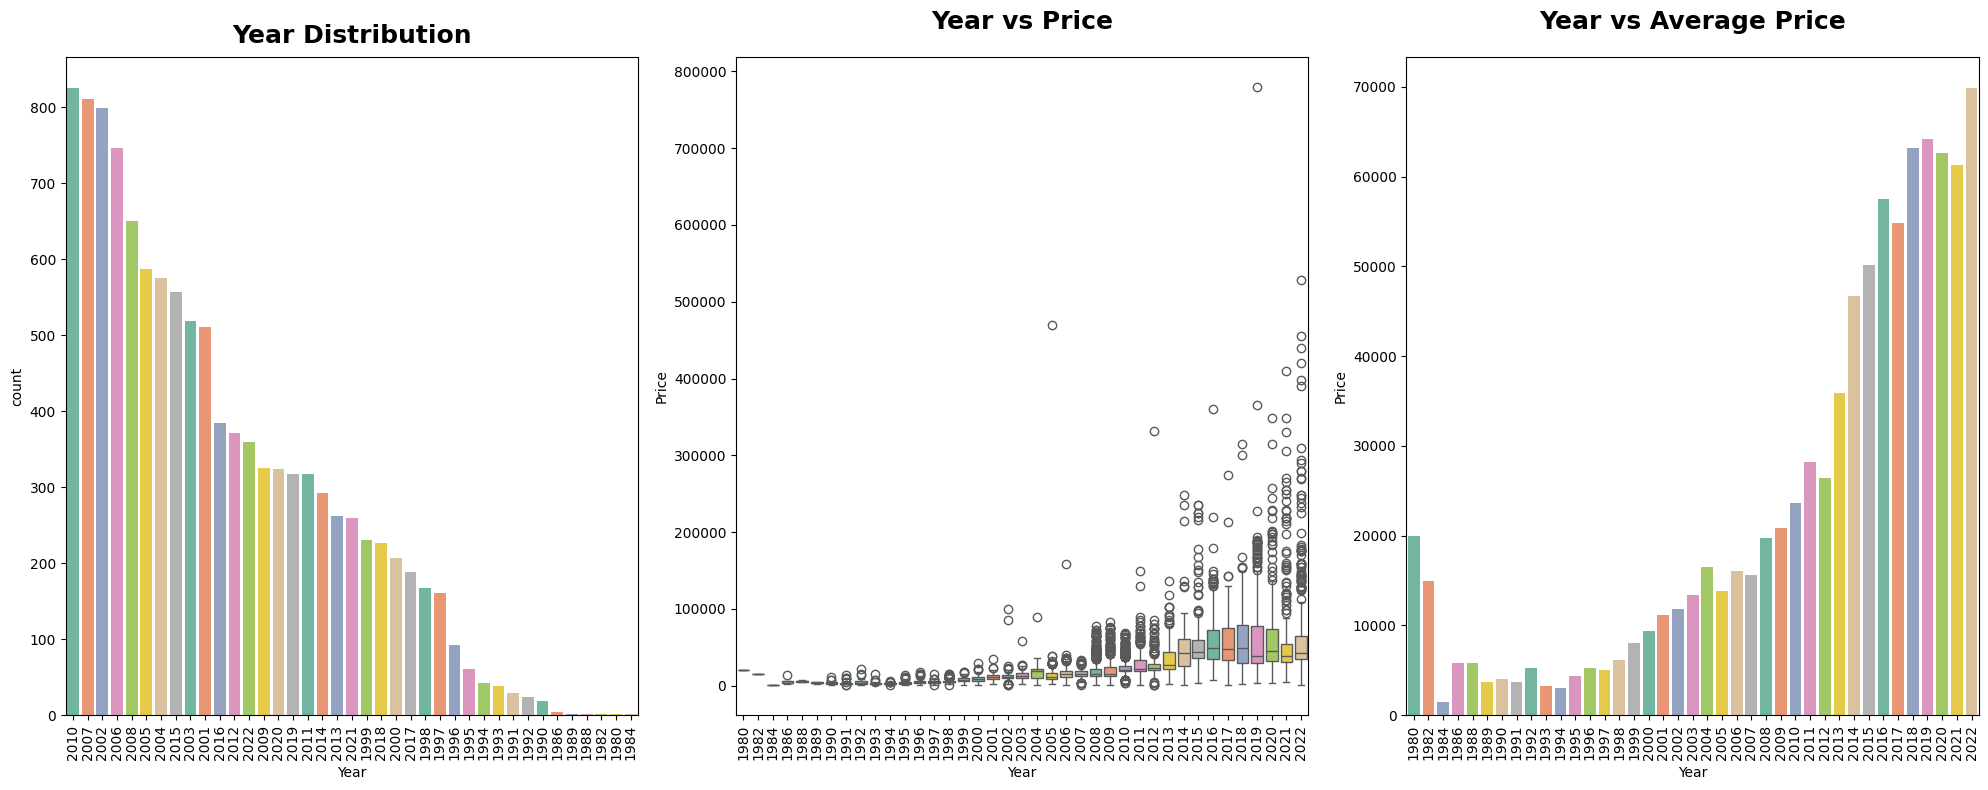

In [320]:
categorical_visualization('Year')

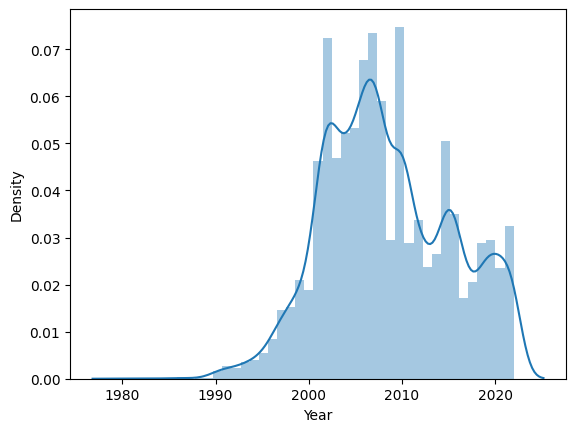

In [321]:
sns.distplot(df['Year'])
plt.show()

In [322]:
def dummy(new_df, categorical_features, threshold=5):
    # Get categorical features that have a number of unique values less than or equal to threshold
    cat_feature = [feature for feature in categorical_features if new_df[feature].nunique() <= threshold]
    
    # Create dummy variables for the selected categorical features
    df_dummy = pd.get_dummies(new_df, columns=cat_feature)
    
    return df_dummy, cat_feature

# Example usage
df_dummy, col_dummy = dummy(df_select, categorical_features, 5)
df_dummy.shape, col_dummy


((11293, 18), ['Tax Type', 'Condition', 'Fuel', 'Transmission'])

#### Observation
 * The average prices seem to have increase from year 2012 to 2022

---

### 10. List of all the useful Feature

**List of all the useful Categorical Features.**
1. Location
2. Car Makes
3. Car Model
4. Tax Type
5. Condition
6. Body Type
7. Fuel
8. Transmission
9. Color

**List of all the useful Numerical Features.**
* Year
* Price

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:black;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
<a id = '4.2'><span>Feature Engineering</span></a>
</p>
</div>

### 1. Deriving New Features From "Cars Makes" Feature. 

* As we made an insight above that we can split the car company name into different price ranges.Like **Low Range, Medium Range, High Range** cars.

In [323]:
z = round(df.groupby(['Car Makes'])['Price'].agg(['mean']), 2)
z.T

Car Makes,Acura,Alfa Romeo,Aston Martin,Audi,BAIC,BMW,BYD,Bentley,CHANGAN,Cadillac,...,SOUEAST,SsangYong,Subaru,Suzuki,Tesla,Toyota,Volkswagen,Volvo,WULING,ZOTYE
mean,88000.0000,48000.0000,130000.0000,32690.3600,33666.6700,36546.5100,24500.0000,130470.5900,32171.4300,71307.6900,...,26857.1400,13346.7900,27166.6700,7685.7100,77006.7700,19905.4100,21060.0000,53799.8600,37800.0000,45500.0000


In [324]:
z.describe()

,mean
count,59.0000
mean,57830.9524
std,68879.3077
min,2100.0000
25%,23564.4700
50%,33994.2000
75%,56793.7650
max,382333.3300


In [325]:
min, max = z.agg(['min','max']).values

In [326]:
# df.drop(columns=['mean_x', 'mean_y'], axis=1, inplace= True)

In [327]:
df1 = df.merge(z, how = 'left', on = 'Car Makes')
df1.shape, df.shape

((11293, 17), (11293, 16))

In [328]:
min, max

(array([2100.]), array([382333.33]))

In [329]:
bin_width = (min+max)/3 
bin_width

array([128144.44333333])

In [330]:
import numpy as np

bins = [i for i in range(int(24600.9100), int(np.ceil(max)), int(np.ceil(bin_width)))]
bins[-1] = int(np.ceil(max))
bins.insert(0, 0)
bins

[0, 24600, 152745, 382334]

In [331]:
cars_bin = ['Budget', 'Medium', 'Highend']
df1['CarsRange'] = pd.cut(df1['mean'], bins=bins, right=False, labels=cars_bin)
df1.head(2)

,Ad ID,Category,Locations,Posted,Car Makes,Car Model,Year,Tax Type,Condition,Body Type,Fuel,Transmission,Color,Link,Title,Price,mean,CarsRange
0,9539303,Cars for Sale,Phnom Penh,10-Jun-23,Toyota,Highlander,2003,Plate Number,Used,Sports,Petrol,Auto,Black,https://www.khmer24.com/en/cars/highlander-%E1...,Highlander ឆ្នាំ 2003 ម៉ាសុីន 4 ប៉ុង 1 ពណ័ ខ្មៅ,14000.0000,19905.4100,Budget
1,9540392,Cars for Sale,Phnom Penh,09-Jun-23,Toyota,Land Cruiser,2022,Plate Number,Used,SUV,Petrol,Auto,Black,https://www.khmer24.com/en/cars/%E1%9E%9B%E1%9...,លក់ Land Cruiser 2022,155000.0000,19905.4100,Budget


**Note**
* In above output we fetched the **avergae price of each individual car companies**
* Now we have to add this average values a new column in our datset.

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:black;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
<a id = '5'><span>Data Preprocessiong</span></a>
</p>
</div>

### 1. Creating new DataFrame with all the useful Features.

In [332]:
df_select = df.drop(columns=['Ad ID ', 'Category ', 'Posted ', 'Link','Title'], axis= 1)
df_select.describe(include= 'O')

,Locations,Car Makes,Car Model,Tax Type,Condition,Body Type,Fuel,Transmission,Color
count,11293,11293,11293,11293,11293,11293,11293,11293,11293
unique,25,59,418,2,2,8,5,2,13
top,Phnom Penh,Toyota,Prius,Plate Number,Used,SUV,Petrol,Auto,White
freq,9598,5780,1935,8594,8966,4614,7261,10904,4797


In [333]:
df_select.iloc[:, 1:].describe().T.sort_values(by='std' , ascending = False)\
                     .style.background_gradient(cmap='GnBu')\
                     .bar(subset=["max"], color='#BB0000')\
                     .bar(subset=["mean",], color='green')

,count,mean,std,min,25%,50%,75%,max
Price,11293.000000,27336.746857,33006.664706,500.000000,11200.000000,17800.000000,30800.000000,780000.000000
Year,11293.000000,2008.456389,6.894490,1980.000000,2003.000000,2008.000000,2014.000000,2022.000000


---

### 1.1 Data with group of CarsRange 

In [334]:
new_df = df1.drop(columns=['Ad ID ', 'Category ', 'Posted ', 'Link', 'mean', 'Car Makes', 'Title', 'Car Model'], axis= 1)
new_df.describe(include=['O', 'category'])

# print(new_df)

,Locations,Tax Type,Condition,Body Type,Fuel,Transmission,Color,CarsRange
count,11293,11293,11293,11293,11293,11293,11293,11293
unique,25,2,2,8,5,2,13,3
top,Phnom Penh,Plate Number,Used,SUV,Petrol,Auto,White,Budget
freq,9598,8594,8966,4614,7261,10904,4797,7129


In [335]:
car_make_Budget = pd.DataFrame(df1[df1['CarsRange'] == 'Budget']['Car Makes'].value_counts()).index.to_list()
car_make_Budget

['Toyota',
 'Kia',
 'Hyundai',
 'Nissan',
 'Honda',
 'Mitsubishi',
 'SsangYong',
 'Isuzu',
 'Mini',
 'Volkswagen',
 'Suzuki',
 'Hawtai Motor',
 'Chrysler',
 'Daewoo',
 'Great Wall',
 'BYD']

In [336]:
car_model_Budget = df[df['Car Makes'].apply(lambda x: x in car_make_Budget)]['Car Model'].value_counts().index.to_list()
car_make_Budget

['Toyota',
 'Kia',
 'Hyundai',
 'Nissan',
 'Honda',
 'Mitsubishi',
 'SsangYong',
 'Isuzu',
 'Mini',
 'Volkswagen',
 'Suzuki',
 'Hawtai Motor',
 'Chrysler',
 'Daewoo',
 'Great Wall',
 'BYD']

In [337]:
df_Budget = pd.DataFrame(df[df['Car Makes'].apply(lambda x: x in car_make_Budget)].groupby(['Car Makes'])['Car Model'].value_counts()).rename(columns={'Car Model': 'Count Number'}).reset_index(level =1)
df_Budget.head()

,Car Model,count
Car Makes,,
BYD,E2,1
Chrysler,300C,1
Daewoo,Lanos,1
Great Wall,Poer-1,1
Hawtai Motor,A25,4


In [338]:
def insight_range_price(car_make_Budget, car_model_Budget, df_Budget, range_price):
    print(f'\033[94m')
    print(f'The total number of Car brands and Car models in range of {range_price} prices',df_Budget.shape[0])
    print(f'The total number of Car brands in range of {range_price} prices', len(car_make_Budget))
    print(f'The total number of Car models in range of {range_price} prices', len(car_model_Budget))

In [339]:
insight_range_price(car_make_Budget, car_model_Budget, df_Budget, 'Budget')


The total number of Car brands and Car models in range of Budget prices 155
The total number of Car brands in range of Budget prices 16
The total number of Car models in range of Budget prices 153


---

In [340]:
car_make_Medium = pd.DataFrame(df1[df1['CarsRange'] == 'Medium']['Car Makes'].value_counts()).index.to_list()

In [341]:
car_model_Medium = df[df['Car Makes'].apply(lambda x: x in car_make_Medium)]['Car Model'].value_counts().index.to_list()

In [342]:
df_model_Medium = pd.DataFrame(df[df['Car Makes'].apply(lambda x: x in car_make_Medium)].groupby(['Car Makes'])['Car Model'].value_counts()).rename(columns={'Car Model': 'Count Number'}).reset_index(level =1)
df_model_Medium.head()

,Car Model,count
Car Makes,,
Acura,MDX,1
Alfa Romeo,Giulia,1
Aston Martin,Rapide,1
Audi,Q7,71
Audi,A7,23


In [343]:
insight_range_price(car_make_Medium, car_model_Medium, df_model_Medium, 'Medium')


The total number of Car brands and Car models in range of Medium prices 258
The total number of Car brands in range of Medium prices 39
The total number of Car models in range of Medium prices 255


---

In [344]:
car_make_Highend= pd.DataFrame(df1[df1['CarsRange'] == 'Highend']['Car Makes'].value_counts()).index.to_list()

In [345]:
car_model_Highend = df[df['Car Makes'].apply(lambda x: x in car_make_Highend)]['Car Model'].value_counts().index.to_list()

In [346]:
df_Highend = pd.DataFrame(df[df['Car Makes'].apply(lambda x: x in car_make_Highend)].groupby(['Car Makes'])['Car Model'].value_counts()).rename(columns={'Car Model': 'Count Number'}).reset_index(level =1)
df_Highend.head()

,Car Model,count
Car Makes,,
Ferrari,488 Spider,2
Ferrari,458 Italia,1
Lamborghini,Aventador,1
Lamborghini,Huracán,1
Lamborghini,Urus,1


In [347]:
insight_range_price(car_make_Highend, car_model_Highend, df_Highend, 'Highend')


The total number of Car brands and Car models in range of Highend prices 11
The total number of Car brands in range of Highend prices 4
The total number of Car models in range of Highend prices 11


---

#### Insight
* we do group of car make by mean price and create new column instead of column car make 
* We still have the large number of categories in another feature
* We choose df_select to use

---

In [348]:
new_year = df['Year'].max()-df['Year']
df['Year'].max()
# df['Year']

np.int64(2022)

In [349]:
new_year.values

array([19,  0, 18, ...,  9, 20,  3])

In [350]:
new_df['lifespan'] = new_year.values
new_df.head()

,Locations,Year,Tax Type,Condition,Body Type,Fuel,Transmission,Color,Price,CarsRange,lifespan
0,Phnom Penh,2003,Plate Number,Used,Sports,Petrol,Auto,Black,14000.0000,Budget,19
1,Phnom Penh,2022,Plate Number,Used,SUV,Petrol,Auto,Black,155000.0000,Budget,0
2,Phnom Penh,2004,Plate Number,Used,SUV,Petrol,Auto,Gray,20500.0000,Medium,18
3,Phnom Penh,2013,Tax Paper,Used,Sedan,Petrol,Auto,Blue,9800.0000,Budget,9
4,Phnom Penh,2013,Plate Number,Used,SUV,Petrol,Auto,White,23500.0000,Medium,9


In [351]:
new_df.drop(columns=['Year'], inplace=True)

### 2. Handling Categorical

### 2.1 Dummy Encoding 

### 2.1.1 With high cadinality 

In [352]:
# Categorical Features
categorical_features = df_select.select_dtypes(include=['object']).columns.tolist()
categorical_features

['Locations ',
 'Car Makes',
 'Car Model',
 'Tax Type',
 'Condition',
 'Body Type',
 'Fuel',
 'Transmission',
 'Color']

In [353]:
def dummy(new_df, categorical_features, threshold=5):
    # Get categorical features that have a number of unique values less than or equal to threshold
    cat_feature = [feature for feature in categorical_features if new_df[feature].nunique() <= threshold]
    
    # Create dummy variables for the selected categorical features
    df_dummy = pd.get_dummies(new_df, columns=cat_feature)
    
    return df_dummy, cat_feature

# Example usage
df_dummy, col_dummy = dummy(df_select, categorical_features, 5)
df_dummy.shape, col_dummy


((11293, 18), ['Tax Type', 'Condition', 'Fuel', 'Transmission'])

### 2.1.2 With low cadinality 

In [354]:
# Categorical Features
categorical_features_new_df = new_df.select_dtypes(include=['object', 'category']).columns
categorical_features_new_df

Index(['Locations ', 'Tax Type', 'Condition', 'Body Type', 'Fuel',
       'Transmission', 'Color', 'CarsRange'],
      dtype='object')

In [355]:
new_df[categorical_features_new_df].describe()

,Locations,Tax Type,Condition,Body Type,Fuel,Transmission,Color,CarsRange
count,11293,11293,11293,11293,11293,11293,11293,11293
unique,25,2,2,8,5,2,13,3
top,Phnom Penh,Plate Number,Used,SUV,Petrol,Auto,White,Budget
freq,9598,8594,8966,4614,7261,10904,4797,7129


In [356]:
new_df_dummy, col_dummy = dummy(new_df, categorical_features_new_df, 50)
new_df_dummy.shape, col_dummy

((11293, 62),
 ['Locations ',
  'Tax Type',
  'Condition',
  'Body Type',
  'Fuel',
  'Transmission',
  'Color',
  'CarsRange'])

---

### 3. Handling Skewdata 

<details>
    
**What is Skewed Data?**

> A data is called as skewed when curve appears distorted either to the left or to the right, in a statistical distribution.I.e one tail is longer than the other.

Such data can be handled by following ways:

-  Log Transform
-  Box Cox Transform
-  Square Root Transform
    

    
    
    </details>

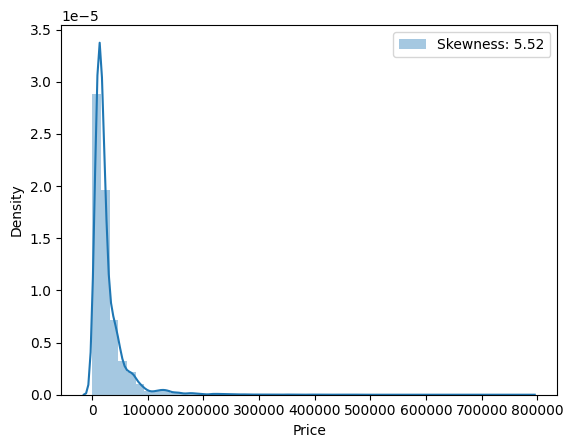

In [357]:
# initial skewness on 'Price'col
#as this is more correlated col 

t = sns.distplot(df_select["Price"],label="Skewness: %.2f"%(df_select["Price"].skew()) )
t.legend();

---

#### 3.2 Log Transform 

-  This is most commonly used
-  Easily done by np.log()
-  Data should not have null values
-  Handle values at 0 (np.log(0) encounters divide by zero)

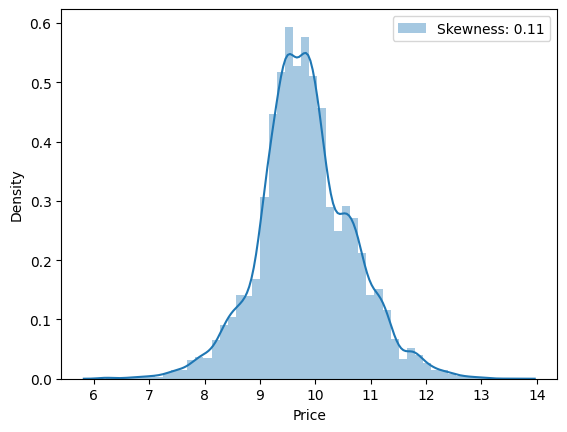

In [358]:
# after log-transform

Log_Ave = df_select["Price"].map(lambda i: np.log(i) if i > 0 else 0)
t = sns.distplot(Log_Ave,label="Skewness: %.2f"%(Log_Ave.skew()) )
t.legend()

##### Insight
>Skewness is reduced from 5.27 to 0.07

---

#### 3.3  Sqare Root Transform

- Not generally used as taking square root shortens the range of variables
- Can be applied via np.sqrt()

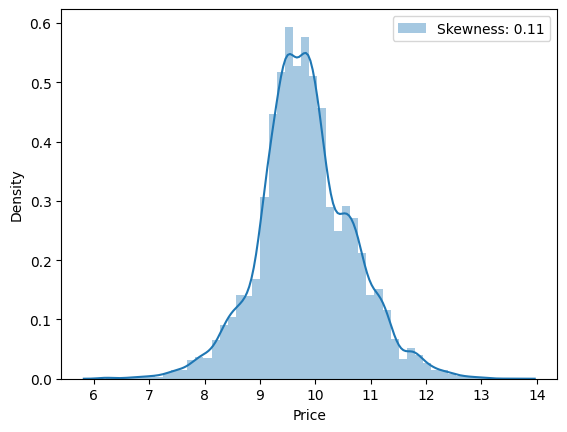

In [359]:
Sqrt_Ave = df_select["Price"].map(lambda i: np.sqrt(i))
t = sns.distplot(Log_Ave,label="Skewness: %.2f"%(Log_Ave.skew()) )
t.legend()

##### Insight
>Skewness is reduced from 5.27 tmo 0.19

---

#### 3. 4 Box Cox Transform

-  Here Data must be positive
- y = ((lambda * x) + 1) ** (1 / lambda)

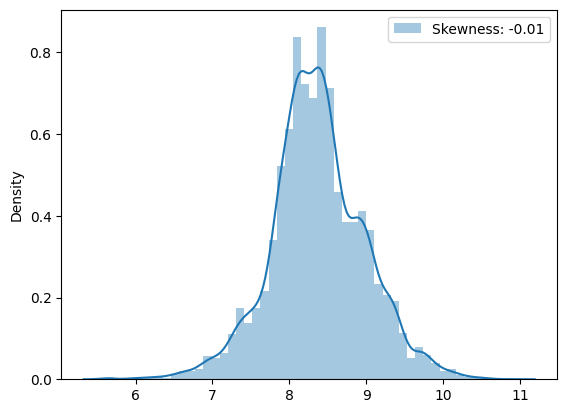

In [360]:
# from scipy import stats
from scipy import *

def boxcox(new_df, col):

    # Box-Cox transformation
    transformed_data, lambda_param = stats.boxcox(new_df[col])

    Boxcox = pd.Series(transformed_data)
    
    t=sns.distplot(Boxcox,label="Skewness: %.2f"%(Boxcox.skew()) )
    t.legend()
    return Boxcox, lambda_param

Price_boxcox, Price_lambda = boxcox(df_select, 'Price')

##### Insight
>Skewness is reduced from 5.27 to -0.00

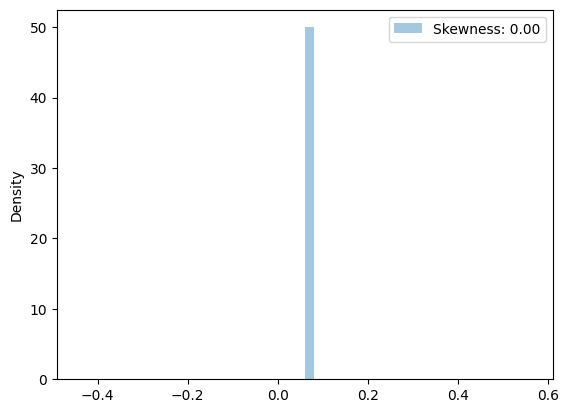

In [361]:
year_boxcox, year_lambda = boxcox(df_select, 'Year')

In [418]:
df_boxcox = df_select.copy()
df_boxcox['Price'] = list(Price_boxcox)
# df_boxcox.Price

0       8.1730
2       9.8519
3       8.4484
6       7.9123
7       8.5462
         ...  
17862   8.7656
17863   7.9971
17866   8.8641
17867   7.7245
17872   9.5558
Name: Price, Length: 11293, dtype: float64

In [363]:
df_boxcox.shape, df_select.shape

((11293, 11), (11293, 11))

In [364]:
new_df_boxcox = new_df_dummy.copy()
new_df_boxcox['Price'] = list(Price_boxcox)

In [365]:
new_df_boxcox.shape, df_select.shape

((11293, 62), (11293, 11))

---

#### 3.4.2 Define original values 

In [366]:
# To find the original data
from scipy.special import inv_boxcox

original_data = inv_boxcox(Price_boxcox, Price_lambda)
original_data.head(10)

0    14000.0000
1   155000.0000
2    20500.0000
3     9800.0000
4    23500.0000
5     7900.0000
6   109100.0000
7    60900.0000
8    42500.0000
9    73000.0000
dtype: float64

In [403]:
df_select['Price'].head(10)

0     14000.0000
2    155000.0000
3     20500.0000
6      9800.0000
7     23500.0000
11     7900.0000
12   109100.0000
14    60900.0000
16    42500.0000
17    73000.0000
Name: Price, dtype: float64

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

### 4 Standard Scaler 

In [368]:
from sklearn.preprocessing import StandardScaler

# Creat function to transform
def scaler_df(df, numerical_features):
    scaler = StandardScaler()
    numerical_features = scaler.fit_transform(df[[numerical_features]])
    return numerical_features

# df_boxcox['Year'] = scaler_df(df_select, 'Year')

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

### 5 Handling Outliers

<img src="https://media.tenor.com/4T5hjh17a18AAAAM/sanditon-theojames.gif" width= 450 height = 400 />

<details>
    
**An outlier is an observation that is unlike the other observations. It is rare, or distinct, or does not fit in some way. It is also called anomalies.**

Outliers can have many causes, such as:
- Measurement or input error.
- Data corruption.
- True outlier observation.

There is no precise way to define and identify outliers in general because of the specifics of each dataset. Instead, you, or a domain expert, must interpret the raw observations and decide whether a value is an outlier or not.

- Nevertheless, we can use **statistical methods** to identify observations that appear to be rare or unlikely given the available data.
- This does not mean that **the values identified are outliers** and should be removed.
- A good tip is to consider plotting the identified outlier values, perhaps in the context of       non-outlier values to see if there are any **systematic relationships or patterns** to the           outliers. 

- If there is, perhaps they are not outliers and can be explained, or perhaps the outliers themselves can be identified more systematically.    
 
#### **Impact Of Outliers:**
-  It increases the **error variance and reduces the power** of statistical tests
-  If the outliers are non-randomly distributed, they can **decrease normality**
-  They can bias or influence estimates that may be of substantive interest
-  They can also **impact the basic assumption** of Regression, ANOVA and other statistical model assumptions.
    
## **Outlier Detection Techniques:**
### **A) Univariate Outliers:**
# **1) Interquartile Range Method:**

- The concept of the Interquartile Range **(IQR) is used to build the boxplot graphs.** IQR is a concept in statistics that is used to measure the statistical dispersion and data variability by dividing the dataset into quartiles.

- In simple words, any dataset or any set of observations is divided into four defined intervals based upon the values of the data and how they compare to the entire dataset. **A quartile is what divides the data into three points and four intervals.**

- It is the difference between the third quartile and the first quartile (IQR = Q3 -Q1). Outliers in this case are defined as the observations that are below (Q1 − 1.5x IQR) or boxplot lower whisker or above (Q3 + 1.5x IQR) or boxplot upper whisker. It can be visually represented by the box plot.
<img src="https://www.thoughtco.com/thmb/S9Y2kXCgZdO4ics_6mWXUjNnmAg=/1500x0/filters:no_upscale():max_bytes(150000):strip_icc():format(webp)/boxplotwithoutliers-5b8ec88846e0fb0025192f90.jpg" width= 450 height = 400 />
    </details>

#### A) Univariate Outliers:
#### 1) Interquartile Range Method:

In [369]:
# func to Interquartile Range Method
def out_iqr(df , column):
    global lower,upper
    q25, q75 = np.quantile(df[column], 0.25), np.quantile(df[column], 0.75)
    # calculate the IQR
    iqr = q75 - q25
    # calculate the outlier cutoff
    cut_off = iqr * 1.5
    # calculate the lower and upper bound value
    lower, upper = q25 - cut_off, q75 + cut_off
    print('The IQR is',iqr)
    print('The lower bound value is', lower)
    print('The upper bound value is', upper)
    # Calculate the number of records below and above lower and above bound value respectively
    df1 = df[df[column] > upper]
    df2 = df[df[column] < lower]
    return print('Total number of outliers are', df1.shape[0]+ df2.shape[0])

In [370]:
def visulize_outlier(df, col):
    out_iqr(df, col)
    plt.figure(figsize = (10,6))
    sns.distplot(df[col], kde=False)
    plt.axvspan(xmin = lower,xmax= df.Price.min(),alpha=0.2, color='red')
    plt.axvspan(xmin = upper,xmax= df.Price.max(),alpha=0.2, color='red')
    plt.show()

In [371]:
def outlier_detection(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3-Q1
    upper_end = Q3+1.5*IQR
    lower_end = Q1 - 1.5*IQR
    outlier = df[(df>upper_end) | (df<lower_end)]
    return outlier

The IQR is 0.7282655950746157
The lower bound value is 6.917862651115043
The upper bound value is 9.830925031413507
Total number of outliers are 298


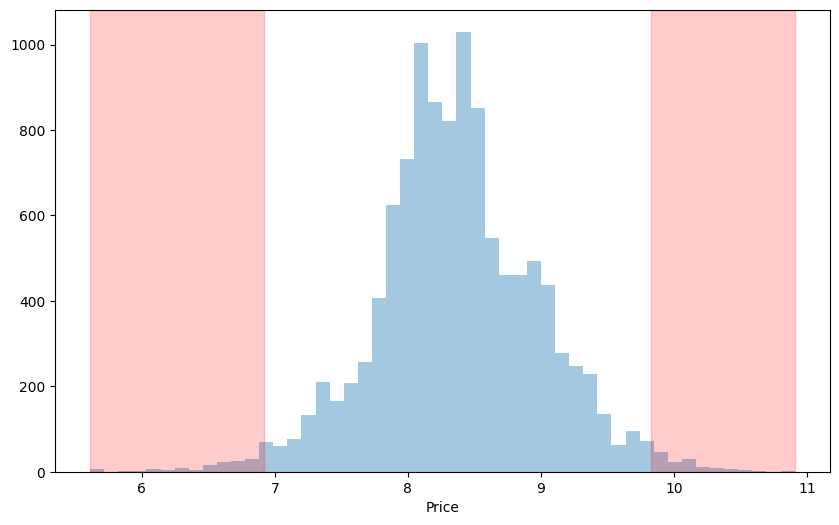

In [372]:
visulize_outlier(df_boxcox, 'Price')

The IQR is 19600.0
The lower bound value is -18200.0
The upper bound value is 60200.0
Total number of outliers are 974


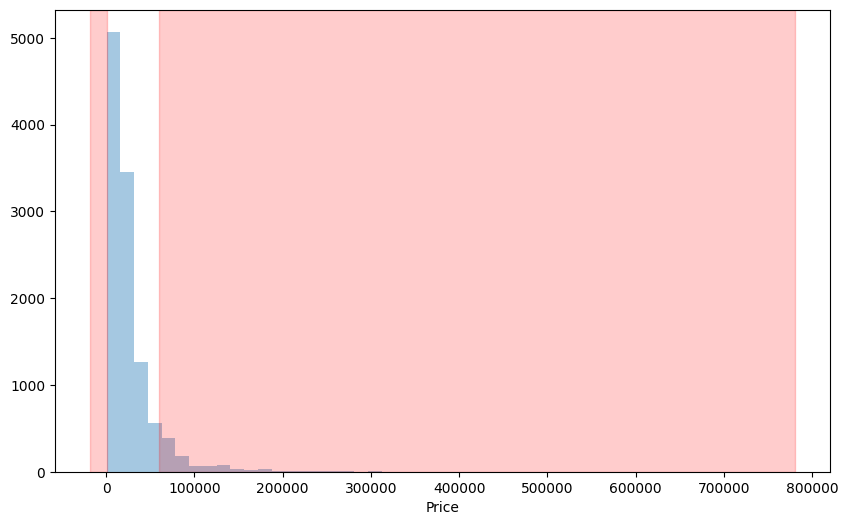

In [373]:
visulize_outlier(df_select, 'Price')

##### Insight
- Here the **red zone represents the outlier zone!** The records present in that zone are considered as outliers .
- **Remedial Measure:**
>Remove the records which are above the upper bound value and records below the lower bound value!

#### **2. Z-Score method:**
<br>
<details>
    
- The Z-score is the **signed number of standard deviations** by which the value of an observation or data point is above the mean value of what is being observed or measured.
- The intuition behind Z-score is **to describe any data point by finding their relationship with     the Standard Deviation and Mean of the group of data points.** Z-score is finding the               distribution of data where mean is 0 and standard deviation is 1 i.e. normal distribution.

- while calculating the Z-score we **re-scale and center the data and look for data points** which are too far from zero. These data points which are way too **far from zero will be treated as the outliers**. In most of the cases a threshold of **3 or -3 is used** i.e if the Z-score value is greater than or less than 3 or -3 respectively, that data point will be identified as outliers.

- This technique assumes a **Gaussian distribution of the data.** The outliers are the data points that are in the tails of the distribution and therefore far from the mean. How far depends on a set threshold zthr for the normalized data points zi calculated with the formula:

**Z_score= (Xi - mean) / standard deviation**

where **Xi is a data point**, **'mean' is the mean of all X** and **'standard deviation' the standard deviation of all X.**

- An outlier is then a normalized data point which has an absolute value greater than Zthr. That is:
### **|Z_score| > Zthr**

- Commonly used Zthr values are 2.5, 3.0 and 3.5. Here we will be using 3.0
- For example, I'll take up the TMedical Cost Personal Datasets for explaining Z-Score method.
    </details>

In [374]:
def out_zscore(data):
    global outliers,zscore
    outliers = []
    zscore = []
    threshold = 3
    mean = np.mean(data)
    std = np.std(data)
    for i in data:
        z_score= (i - mean)/std 
        zscore.append(z_score)
        if np.abs(z_score) > threshold:
            outliers.append(i)
    return print("Total number of outliers are",len(outliers))

Total number of outliers are 231
0    14000.0000
2   155000.0000
3    20500.0000
6     9800.0000
7    23500.0000
Name: Price, dtype: float64


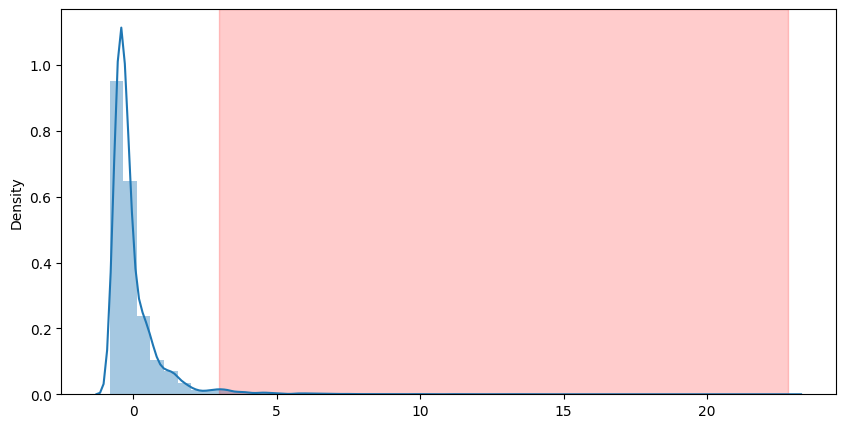

In [405]:
out_zscore(df_select.Price)
print(df_select.Price.head())
plt.figure(figsize = (10,5))
sns.distplot(zscore)
plt.axvspan(xmin = 3 ,xmax= np.max(zscore),alpha=0.2, color='red')
plt.show()

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

### B) **MULTIVARIATE OUTLIERS:**

#### 3. **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):**
<br>

<details>

- This is a **clustering algorithm (an alternative to K-Means)** that clusters points together and identifies any points not belonging to a cluster as outliers. 

- It’s like K-means, except the number of clusters does not need to be specified in advance .
<img src="https://pic3.zhimg.com/v2-24f949e7d2fc310fba0bcd3d9441beb2_r.jpg" width= 450 height = 400 />
    </details>

In [416]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics

X_db = df_select[['Price']].values
print(X_db)

db = DBSCAN(eps=0.3, min_samples=10).fit(X_db)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points(outliers): %d" % n_noise_)

[[ 14000.]
 [155000.]
 [ 20500.]
 ...
 [ 36800.]
 [  7600.]
 [ 99990.]]
Estimated number of clusters: 259
Estimated number of noise points(outliers): 2532


**here -1 is representing outliers. We have 433 in this case .Let's visualize them**

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

### 4. 1 Handling With remove Outlier 

In [377]:
outlier_index = list(outlier_detection(df_boxcox['Price']).index)

In [378]:
df_ro = df_boxcox.drop(outlier_index, axis= 'rows')
df_select.shape, df_ro.shape

((11293, 11), (10995, 11))

In [379]:
new_df_boxcox.tail()

,Price,lifespan,Locations _Banteay Meanchey,Locations _Battambang,Locations _Kampong Cham,Locations _Kampong Chhnang,Locations _Kampong Speu,Locations _Kampong Thom,Locations _Kampot,Locations _Kandal,...,Color_Green,Color_Orange,Color_Purple,Color_Red,Color_Silver,Color_White,Color_Yellow,CarsRange_Budget,CarsRange_Medium,CarsRange_Highend
11288,8.7656,14,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
11289,7.9971,19,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
11290,8.8641,9,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
11291,7.7245,20,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
11292,9.5558,3,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False


In [415]:
outlier_index = list(outlier_detection(new_df_boxcox['Price']).index)
print(new_df_boxcox.Price)
new_df_ro = new_df_boxcox.drop(outlier_index, axis='rows')
new_df_boxcox.shape[0], new_df_ro.shape[0]



0       8.1730
1       9.8519
2       8.4484
3       7.9123
4       8.5462
         ...  
11288   8.7656
11289   7.9971
11290   8.8641
11291   7.7245
11292   9.5558
Name: Price, Length: 11293, dtype: float64


(11293, 10995)

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

### 5. Target Encoding 

In [382]:
%pip install category_encoders


Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


In [402]:
print(df_ro['Price'])

0       8.1730
3       8.4484
6       7.9123
7       8.5462
11      7.7532
         ...  
17862   8.7656
17863   7.9971
17866   8.8641
17867   7.7245
17872   9.5558
Name: Price, Length: 10995, dtype: float64


In [383]:
import category_encoders as ce
from sklearn.model_selection import train_test_split

df_target = df_ro.copy()
df_target['lifespan'] = new_year
df_target.drop(columns=['Year'], inplace = True)
categorical_features_target = df_target.select_dtypes(include='O').columns.tolist() 

# Split the data into training and validation sets
train, val = train_test_split(df_target, test_size=0.3, random_state=42)

# Initialize the target encoder
target_encoder = ce.TargetEncoder(cols= categorical_features_target)

target_encoder.fit(train[categorical_features_target], train['Price'])

# Encode the categorical variable for both training and validation data
train_encoded = target_encoder.transform(train[categorical_features_target])
val_encoded = target_encoder.transform(val[categorical_features_target])

# Combine the encoded variable with the original data
train = pd.concat([train.drop(categorical_features_target, axis=1), train_encoded], axis=1)
val = pd.concat([val.drop(categorical_features_target, axis=1), val_encoded], axis=1)

In [116]:
# target_encoder.ordinal_encoder.mapping

In [117]:
# target_encoder.mapping

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

### 4. Splitting Data for Model Traning & Testing.

In [385]:
x_train,x_test,y_train, y_test= train.drop(columns=['Price'], axis= 1), val.drop(columns=['Price'], axis= 1), train.Price, val.Price

In [387]:
print("x_train - >  ",x_train.shape)
print("x_test - >  ",x_test.shape)
print("y_train - >  ",y_train.shape)
print("y_test - >  ",y_test.shape)

x_train - >   (7696, 10)
x_test - >   (3299, 10)
y_train - >   (7696,)
y_test - >   (3299,)


---

In [388]:
X = new_df_ro.drop('Price', axis= 1)
y = new_df_ro.Price

In [389]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, random_state= 2)

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

---


<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:black;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
<a id = '6'><span>Model Building</span></a>
</p>
</div>

In [390]:
Algorithms = {'Training Score': [],
        'Testing Score' : [],
        'Algorithms': []
        }

In [391]:
from sklearn.metrics import r2_score, mean_squared_error

def model_prediction(x_train, x_test, y_train, y_test, model, name):
    model.fit(x_train,y_train)
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    a = r2_score(y_train,y_train_pred)*100
    b = r2_score(y_test,y_test_pred)*100
    
    Algorithms['Algorithms'].append(name)
    Algorithms['Training Score'].append(a)
    Algorithms['Testing Score'].append(b)
    
    print(f"r2_Score of {model} model on Training Data is:",a)
    print(f"r2_Score of {model} model on Testing Data is:",b)
    print(f"MSE of {model} model on Testing Data is:", mean_squared_error(y_test_pred, y_test))

<a id="1.3"></a>
<h2 style="font-family: Verdana; font-size: 22px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: black; background-color: #ffffff;"><b>1. Linear-Regression </b> Model</h2>

In [394]:
from sklearn.linear_model import LinearRegression
model_prediction(x_train, x_test, y_train, y_test, LinearRegression(), 'Linear Regression')

r2_Score of LinearRegression() model on Training Data is: 78.34262148416656
r2_Score of LinearRegression() model on Testing Data is: 75.74057154199085
MSE of LinearRegression() model on Testing Data is: 0.07032134513208345


---

In [125]:
from sklearn.linear_model import LinearRegression
model_prediction(X_train, X_test, Y_train, Y_test, LinearRegression(), 'Linear Regression with new_df')

r2_Score of LinearRegression() model on Training Data is: 70.33372547744135
r2_Score of LinearRegression() model on Testing Data is: 68.49649301808805
MSE of LinearRegression() model on Testing Data is: 0.09170973953874584


### 1. 1 Feature Selection 

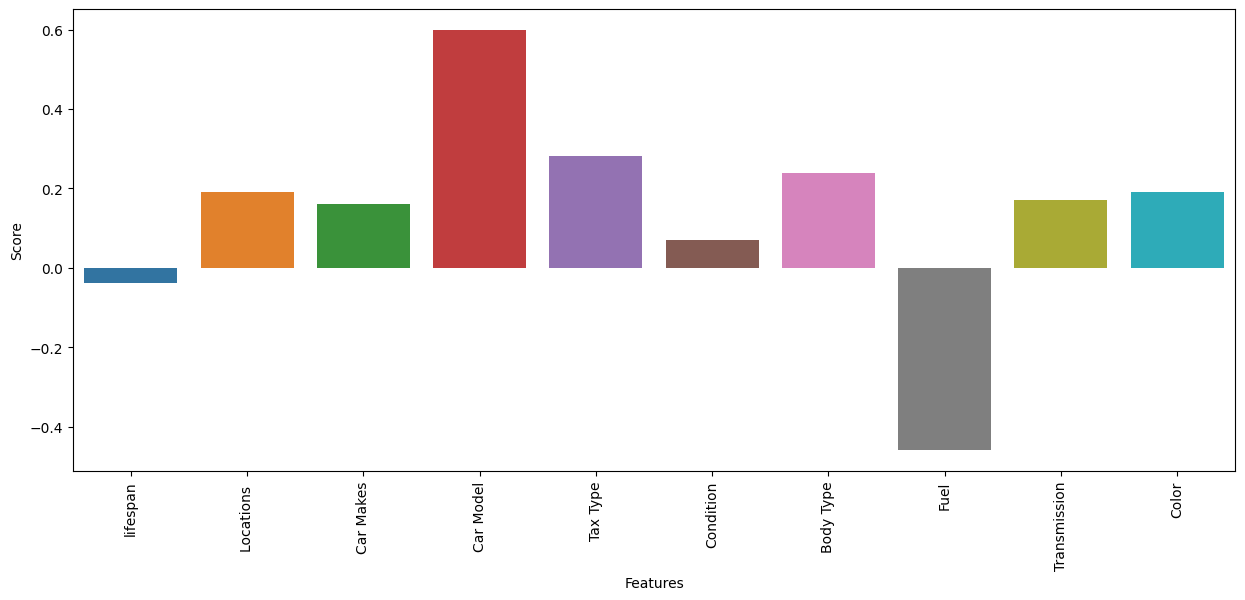

In [126]:
def features_importance(x_train, y_train, lm):
    lm.fit(x_train, y_train)

    df_importance_l_d = pd.DataFrame()
    df_importance_l_d['Features'] = x_train.columns
    df_importance_l_d['Score'] = lm.coef_

    plt.figure(figsize = (15, 6))

    sns.barplot(x= 'Features', y = 'Score', data = df_importance_l_d )
    plt.xticks(rotation = 90)
    plt.show()
    
lm = LinearRegression()
features_importance(x_train, y_train, lm)

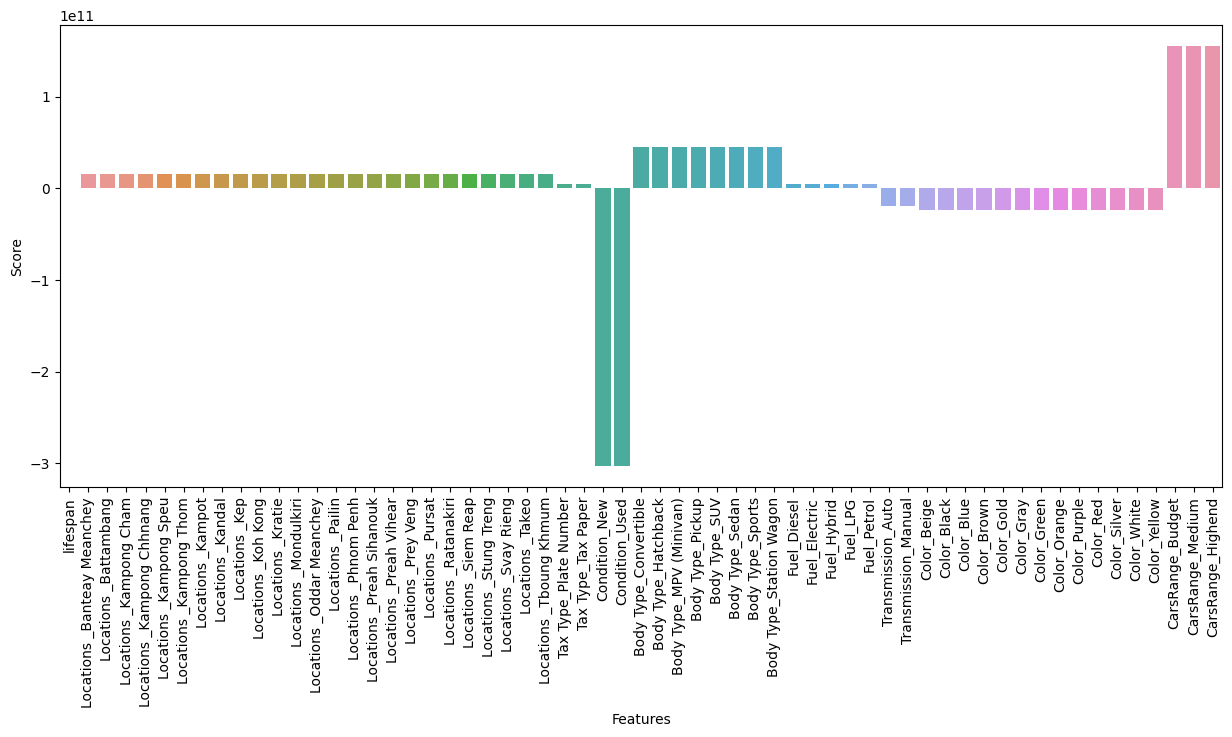

In [127]:
lm = LinearRegression()
features_importance(X_train, Y_train, lm)

### 1. 1. 1.  RFE 

Let's use Recursive feature elimination since we have too many independent variables

In [128]:
def feature_selection_REF(X_train, y_train, lm, n_features_to_select):
    # Running RFE with the output number of the variable equal to 8
    lm.fit(X_train, y_train)

    rfe = RFE(lm, n_features_to_select=n_features_to_select)             
    rfe = rfe.fit(X_train, y_train)

    col_sup = X_train.columns[rfe.support_]
    col_sup
    
    # Creating X_train dataframe with RFE selected variables

    X_train_rfe = X_train[col_sup]
    
    # Selecting the variables which are in support
#     print(list(zip(X_train.columns,rfe.support_,rfe.ranking_)))
#     print('\n')
#     print(X_train_rfe.columns.tolist())
    
    return X_train_rfe

In [188]:
# Adding a constant variable and Build a first fitted model
import statsmodels.api as sm  

def ODL_checking(X_train_rfec, y_train):
    X_train_rfec = sm.add_constant(X_train_rfec)
    lm_rfe = sm.OLS(y_train,X_train_rfec).fit()

    #Summary of linear model
    print(lm_rfe.summary())
    return lm_rfe

In [201]:
def drop_high_pvalue_features(X, y, alpha=0.05):
    """
    Drops one feature at a time based on the p-value until all p-values are less than or equal to the specified alpha level.
    
    Parameters:
        df (pandas DataFrame): The DataFrame to check for high p-values.
        alpha (float): The alpha level above which features will be dropped. Default is 0.05.
    
    Returns:
        pandas DataFrame: The DataFrame with high p-value features dropped.
    """
    model = sm.OLS(y, X)
    results = model.fit()
    
    # Iterate until all p-values are less than or equal to the alpha level
    while results.pvalues.max() > alpha:
        # Drop the feature with the highest p-value
        drop_feature = results.pvalues.idxmax()
        X = X.drop(columns=[drop_feature], axis = 'columns')
        # Fit a new OLS model with the remaining features
        model = sm.OLS(y, X)
        results = model.fit()
    
    return X

In [131]:
def drop_high_vif_features(features, vif_thresh=5):
    """
    Drops one feature at a time based on the VIF value until all VIF values are less than or equal to the specified threshold.
    
    Parameters:
        df (pandas DataFrame): The DataFrame to check for high VIF values.
        vif_thresh (float): The threshold VIF value above which features will be dropped. Default is 5.
    
    Returns:
        pandas DataFrame: The DataFrame with high VIF features dropped.
    """
    vifs = pd.Series([variance_inflation_factor(features.values, i) for i in range(features.shape[1])], index=features.columns)
    
    # Iterate until all VIF values are less than or equal to the threshold
    while vifs.max() > vif_thresh:
        # Drop the feature with the highest VIF value
        drop_feature = vifs.idxmax()
        features = features.drop(columns=[drop_feature])
        
        # Re-calculate VIF values for remaining features
        vifs = pd.Series([variance_inflation_factor(features.values, i) for i in range(features.shape[1])], index=features.columns)
    
    return features

### 1.1.1.1 With hight cadinality 

In [132]:
ODL_checking(x_train, y_train)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     2780.
Date:                Sun, 09 Jul 2023   Prob (F-statistic):               0.00
Time:                        13:34:04   Log-Likelihood:                -450.19
No. Observations:                7696   AIC:                             922.4
Df Residuals:                    7685   BIC:                             998.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -3.1818      0.695     -4.577   

In [133]:
x_train_new = drop_high_pvalue_features(x_train, y_train)
ODL_checking(x_train_new, y_train)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     3087.
Date:                Sun, 09 Jul 2023   Prob (F-statistic):               0.00
Time:                        13:34:04   Log-Likelihood:                -452.24
No. Observations:                7696   AIC:                             924.5
Df Residuals:                    7686   BIC:                             994.0
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -2.8692      0.678     -4.232   

### 1.1.1.1 With low cadinality 

In [134]:
ODL_checking(X_train, Y_train)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     367.8
Date:                Sun, 09 Jul 2023   Prob (F-statistic):               0.00
Time:                        13:34:04   Log-Likelihood:                -1749.5
No. Observations:                8246   AIC:                             3607.
Df Residuals:                    8192   BIC:                             3986.
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [199]:
X_train_new = drop_high_pvalue_features(X_train, Y_train)
ODL_checking(X_train_new, Y_train).pvalues.idxmax()

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     649.9
Date:                Sun, 09 Jul 2023   Prob (F-statistic):               0.00
Time:                        13:50:14   Log-Likelihood:                -1757.4
No. Observations:                8246   AIC:                             3577.
Df Residuals:                    8215   BIC:                             3794.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                   -1

'Color_Beige'

### Checking VIF

Variance Inflation Factor or VIF, gives a basic quantitative idea about how much the feature variables are correlated with each other. It is an extremely important parameter to test our linear model. The formula for calculating `VIF` is:

### $ VIF_i = \frac{1}{1 - {R_i}^2} $
 


In [136]:
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
def VIF(X_train_rfe):
    vif = pd.DataFrame()
    vif['Features'] = X_train_rfe.columns
    vif['VIF'] = [variance_inflation_factor(X_train_rfe.values, i) for i in range(X_train_rfe.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by = "VIF", ascending = False) 
    vif = vif.reset_index(drop = True)
    return vif

In [137]:
VIF(x_train_new)

,Features,VIF
0,Fuel,8703.5400
1,Transmission,8403.0100
2,Tax Type,4467.4500
3,Locations,4060.1200
4,Body Type,3415.5700
5,Color,1684.3400
6,Car Makes,1423.7200
7,Car Model,929.3700
8,lifespan,7.4700


In [138]:
x_train_new1 = drop_high_vif_features(x_train_new)
VIF(x_train_new1)

,Features,VIF
0,lifespan,4.5900
1,Car Model,4.5900


In [139]:
ODL_checking(x_train_new1, y_train)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                 1.216e+04
Date:                Sun, 09 Jul 2023   Prob (F-statistic):               0.00
Time:                        13:34:05   Log-Likelihood:                -849.67
No. Observations:                7696   AIC:                             1705.
Df Residuals:                    7693   BIC:                             1726.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0966      0.085     36.560      0.0

In [173]:
model_prediction(x_train_new1, x_test[x_train_new1.columns.tolist()], y_train, y_test, LinearRegression(), 'Linear Regression')

r2_Score of LinearRegression() model on Training Data is: 75.97339378779662
r2_Score of LinearRegression() model on Testing Data is: 73.3118639205653
MSE of LinearRegression() model on Testing Data is: 0.07736147958595238


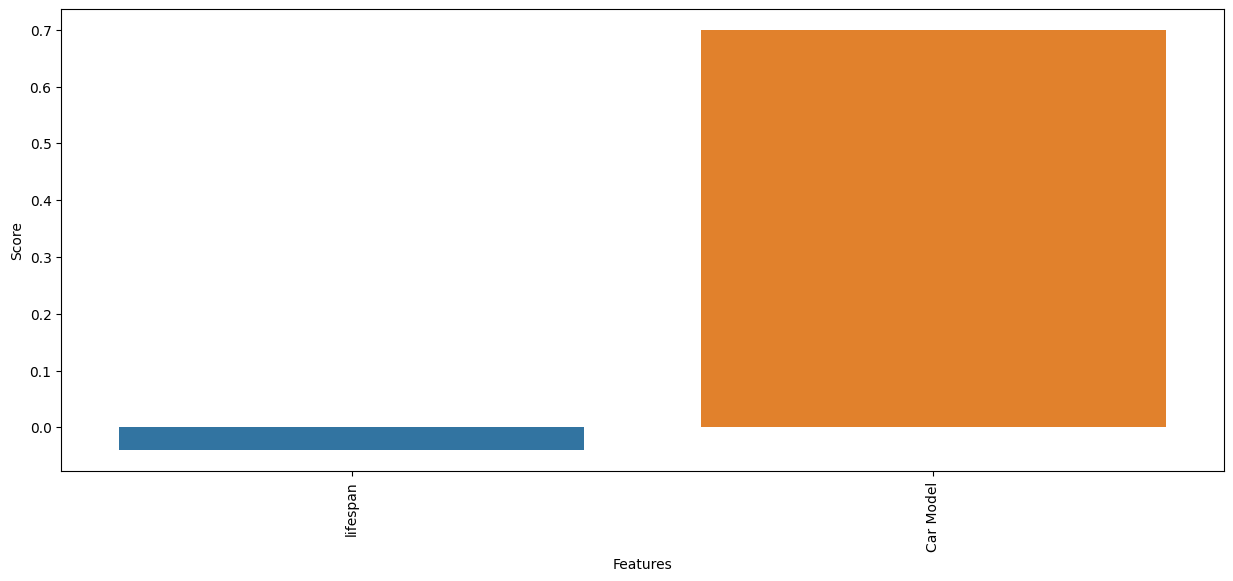

In [140]:
features_importance(x_train_new1, y_train, LinearRegression())

In [141]:
ODL_checking(x_train_new1, y_train)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                 1.216e+04
Date:                Sun, 09 Jul 2023   Prob (F-statistic):               0.00
Time:                        13:34:05   Log-Likelihood:                -849.67
No. Observations:                7696   AIC:                             1705.
Df Residuals:                    7693   BIC:                             1726.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0966      0.085     36.560      0.0

In [142]:
VIF(X_train_new)

,Features,VIF
0,Fuel_Petrol,inf
1,Transmission_Auto,inf
2,Color_Beige,inf
3,Color_Black,inf
4,Color_Blue,inf
5,Color_Brown,inf
6,Color_Gold,inf
7,Color_Gray,inf
8,Color_Green,inf
9,Color_Orange,inf


In [143]:
X_train_new1 = drop_high_vif_features(X_train_new)
VIF(X_train_new1)

,Features,VIF
0,Body Type_Sports,1.0900
1,Fuel_LPG,1.0700
2,Color_Green,1.0600
3,Fuel_Electric,1.0500
4,Color_Yellow,1.0200
5,Color_Purple,1.0100
6,Color_Brown,1.0100
7,Color_Orange,1.0100
8,Body Type_Station Wagon,1.0100
9,CarsRange_Highend,1.0000


In [174]:
model_prediction(X_train_new1, X_test[X_train_new1.columns.tolist()], Y_train, Y_test, LinearRegression(), 'Linear Regression')

r2_Score of LinearRegression() model on Training Data is: 41.05331878233051
r2_Score of LinearRegression() model on Testing Data is: 40.349644189876855
MSE of LinearRegression() model on Testing Data is: 0.17364792427334708


In [144]:
ODL_checking(X_train_new1, Y_train)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     212.0
Date:                Sun, 09 Jul 2023   Prob (F-statistic):               0.00
Time:                        13:34:10   Log-Likelihood:                -4591.5
No. Observations:                8246   AIC:                             9239.
Df Residuals:                    8218   BIC:                             9435.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<a id="1.3"></a>
<h2 style="font-family: Verdana; font-size: 22px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: black; background-color: #ffffff;"><b>2. Decision-Tree-Regressor </b> Model</h2>

In [145]:
from sklearn.tree import DecisionTreeRegressor
model_prediction(x_train, x_test, y_train, y_test, DecisionTreeRegressor(), 'Decission Tree')

r2_Score of DecisionTreeRegressor() model on Training Data is: 98.149103538342
r2_Score of DecisionTreeRegressor() model on Testing Data is: 83.54898661352199
MSE of DecisionTreeRegressor() model on Testing Data is: 0.04768690973690528


In [146]:
def tree_importance(x_train, y_train, dt_hp):
    dt_hp = DecisionTreeRegressor()
    dt_hp.fit(x_train, y_train)
    # let's create a dictionary of features and their importance values
    feat_dict= {}
    for col, val in sorted(zip(x_train.columns, dt_hp.feature_importances_),key=lambda x:x[1],reverse=True):
      feat_dict[col]=val
    feat_df = pd.DataFrame({'Feature':feat_dict.keys(),'Importance':feat_dict.values()})
    values = feat_df.Importance    
    idx = feat_df.Feature
    plt.figure(figsize=(10,int(len(x_train.columns)/4.2)))
    clrs = ['green' if (x < np.max(values)) else 'red' for x in values ]
    sns.barplot(y=idx,x=values,palette=clrs).set(title='Important features to predict Cars Prices')
    plt.show()

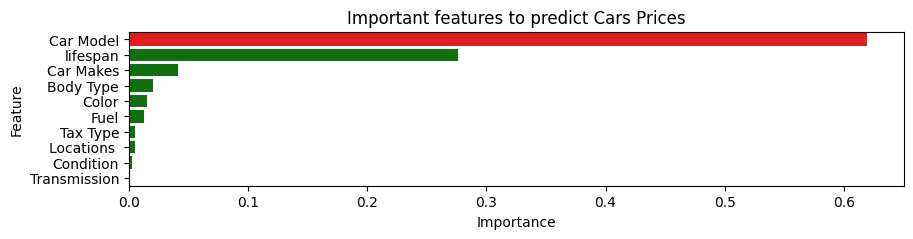

In [147]:
tree_importance(x_train, y_train, DecisionTreeRegressor())

In [148]:
model_prediction(X_train, X_test, Y_train, Y_test, DecisionTreeRegressor(), 'Decission Tree')

r2_Score of DecisionTreeRegressor() model on Training Data is: 91.2093700469768
r2_Score of DecisionTreeRegressor() model on Testing Data is: 71.40273072761765
MSE of DecisionTreeRegressor() model on Testing Data is: 0.0832494019791315


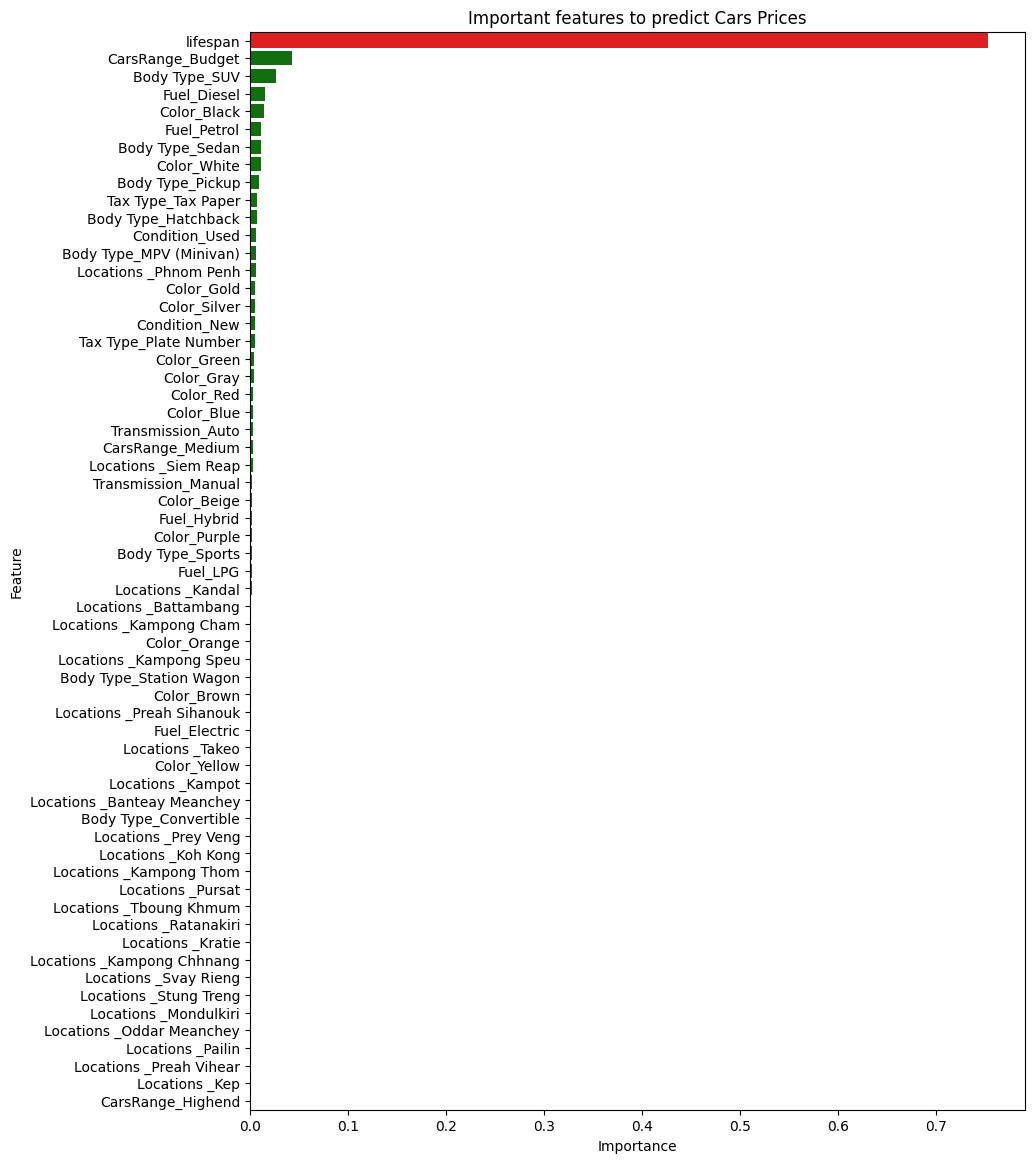

In [149]:
tree_importance(X_train, Y_train, DecisionTreeRegressor())

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<a id="1.3"></a>
<h2 style="font-family: Verdana; font-size: 22px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: black; background-color: #ffffff;"><b>3. Random-Forest-Regressor </b> Model</h2>

In [150]:
from sklearn.ensemble import RandomForestRegressor
model_prediction(x_train, x_test, y_train, y_test, RandomForestRegressor(), 'RandomForestRegressor')

r2_Score of RandomForestRegressor() model on Training Data is: 97.31840021485233
r2_Score of RandomForestRegressor() model on Testing Data is: 88.60217847999807
MSE of RandomForestRegressor() model on Testing Data is: 0.03303911274356161


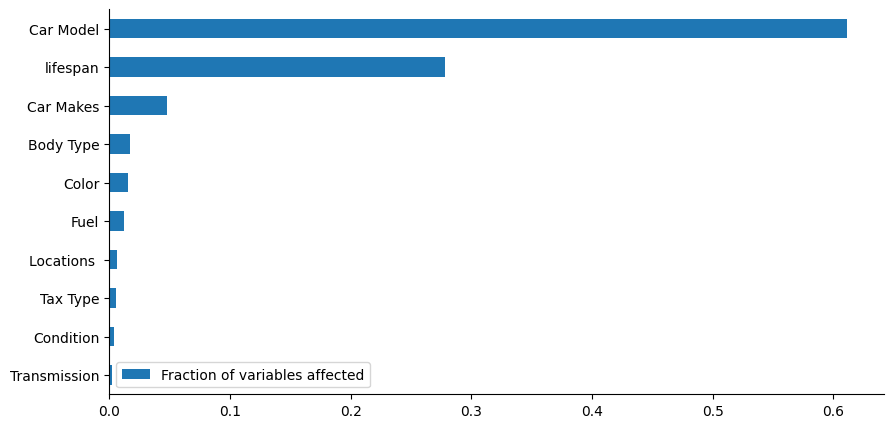

In [151]:
def feature_import_random_forest(rf, X_train, y_train):
    rf.fit(X_train, y_train.values.ravel())
    feat_scores= pd.DataFrame({"Fraction of variables affected" : rf.feature_importances_},index = X_train.columns)
    feat_scores= feat_scores.sort_values(by = "Fraction of variables affected")
    features = len(X_train.columns.tolist())
    feat_scores.plot(kind = "barh", figsize = (10, int(features/2)))
    sns.despine()
feature_import_random_forest(RandomForestRegressor(), x_train, y_train)

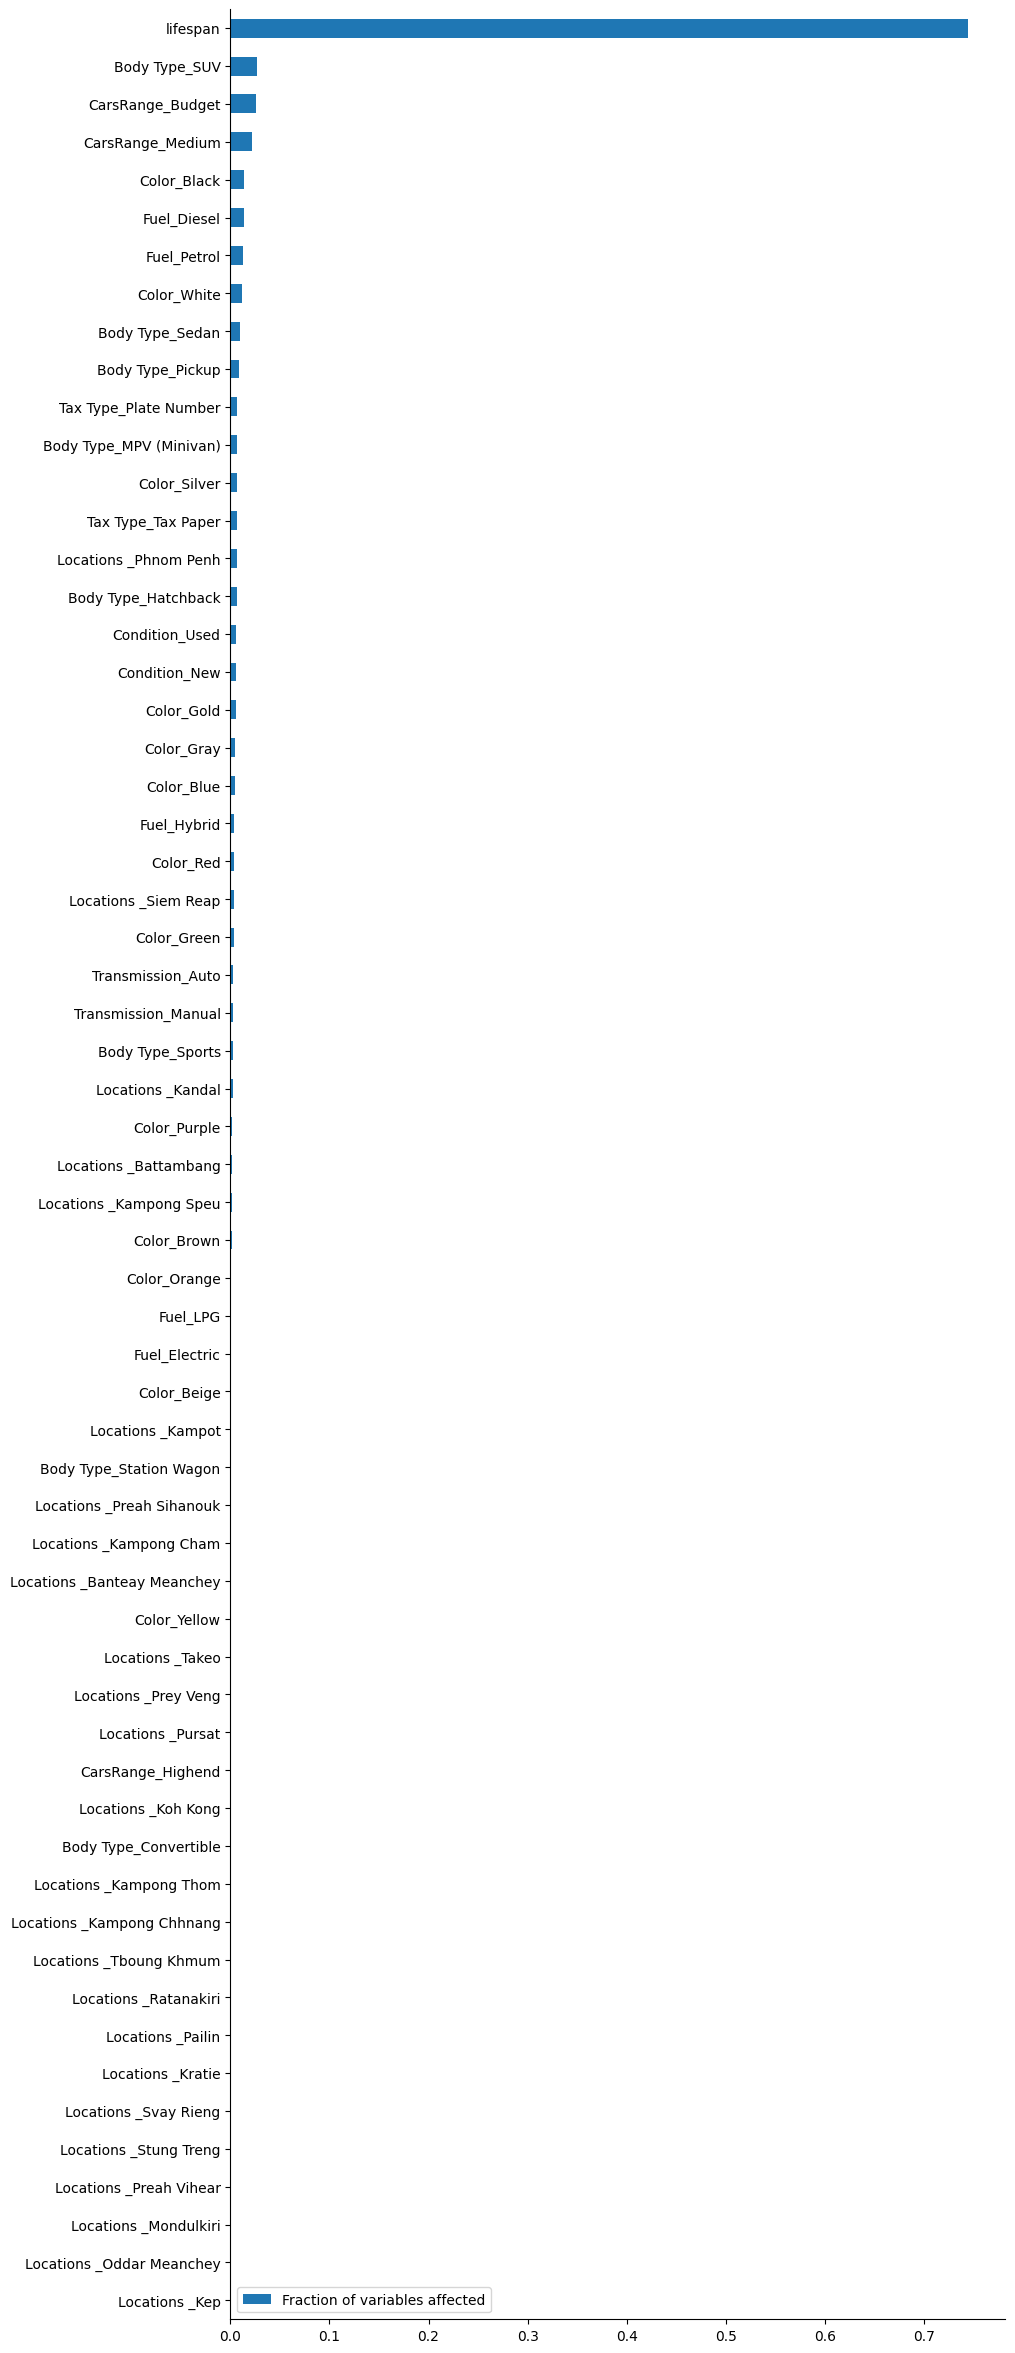

In [152]:
feature_import_random_forest(RandomForestRegressor(), X_train, Y_train)

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<a id="1.3"></a>
<h2 style="font-family: Verdana; font-size: 22px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: black; background-color: #ffffff;"><b>5. Ada-Boost-Regressor </b> Model</h2>

In [153]:
from sklearn.ensemble import AdaBoostRegressor
model_prediction(x_train, x_test, y_train, y_test, AdaBoostRegressor(), 'AdaBoostRegressor')

r2_Score of AdaBoostRegressor() model on Training Data is: 73.81739564109733
r2_Score of AdaBoostRegressor() model on Testing Data is: 69.63083909699971
MSE of AdaBoostRegressor() model on Testing Data is: 0.0880317461754236


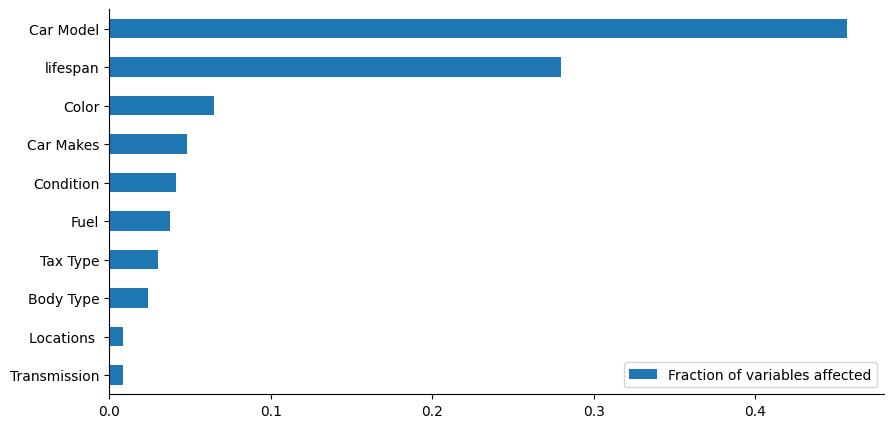

In [154]:
feature_import_random_forest(AdaBoostRegressor(), x_train, y_train)

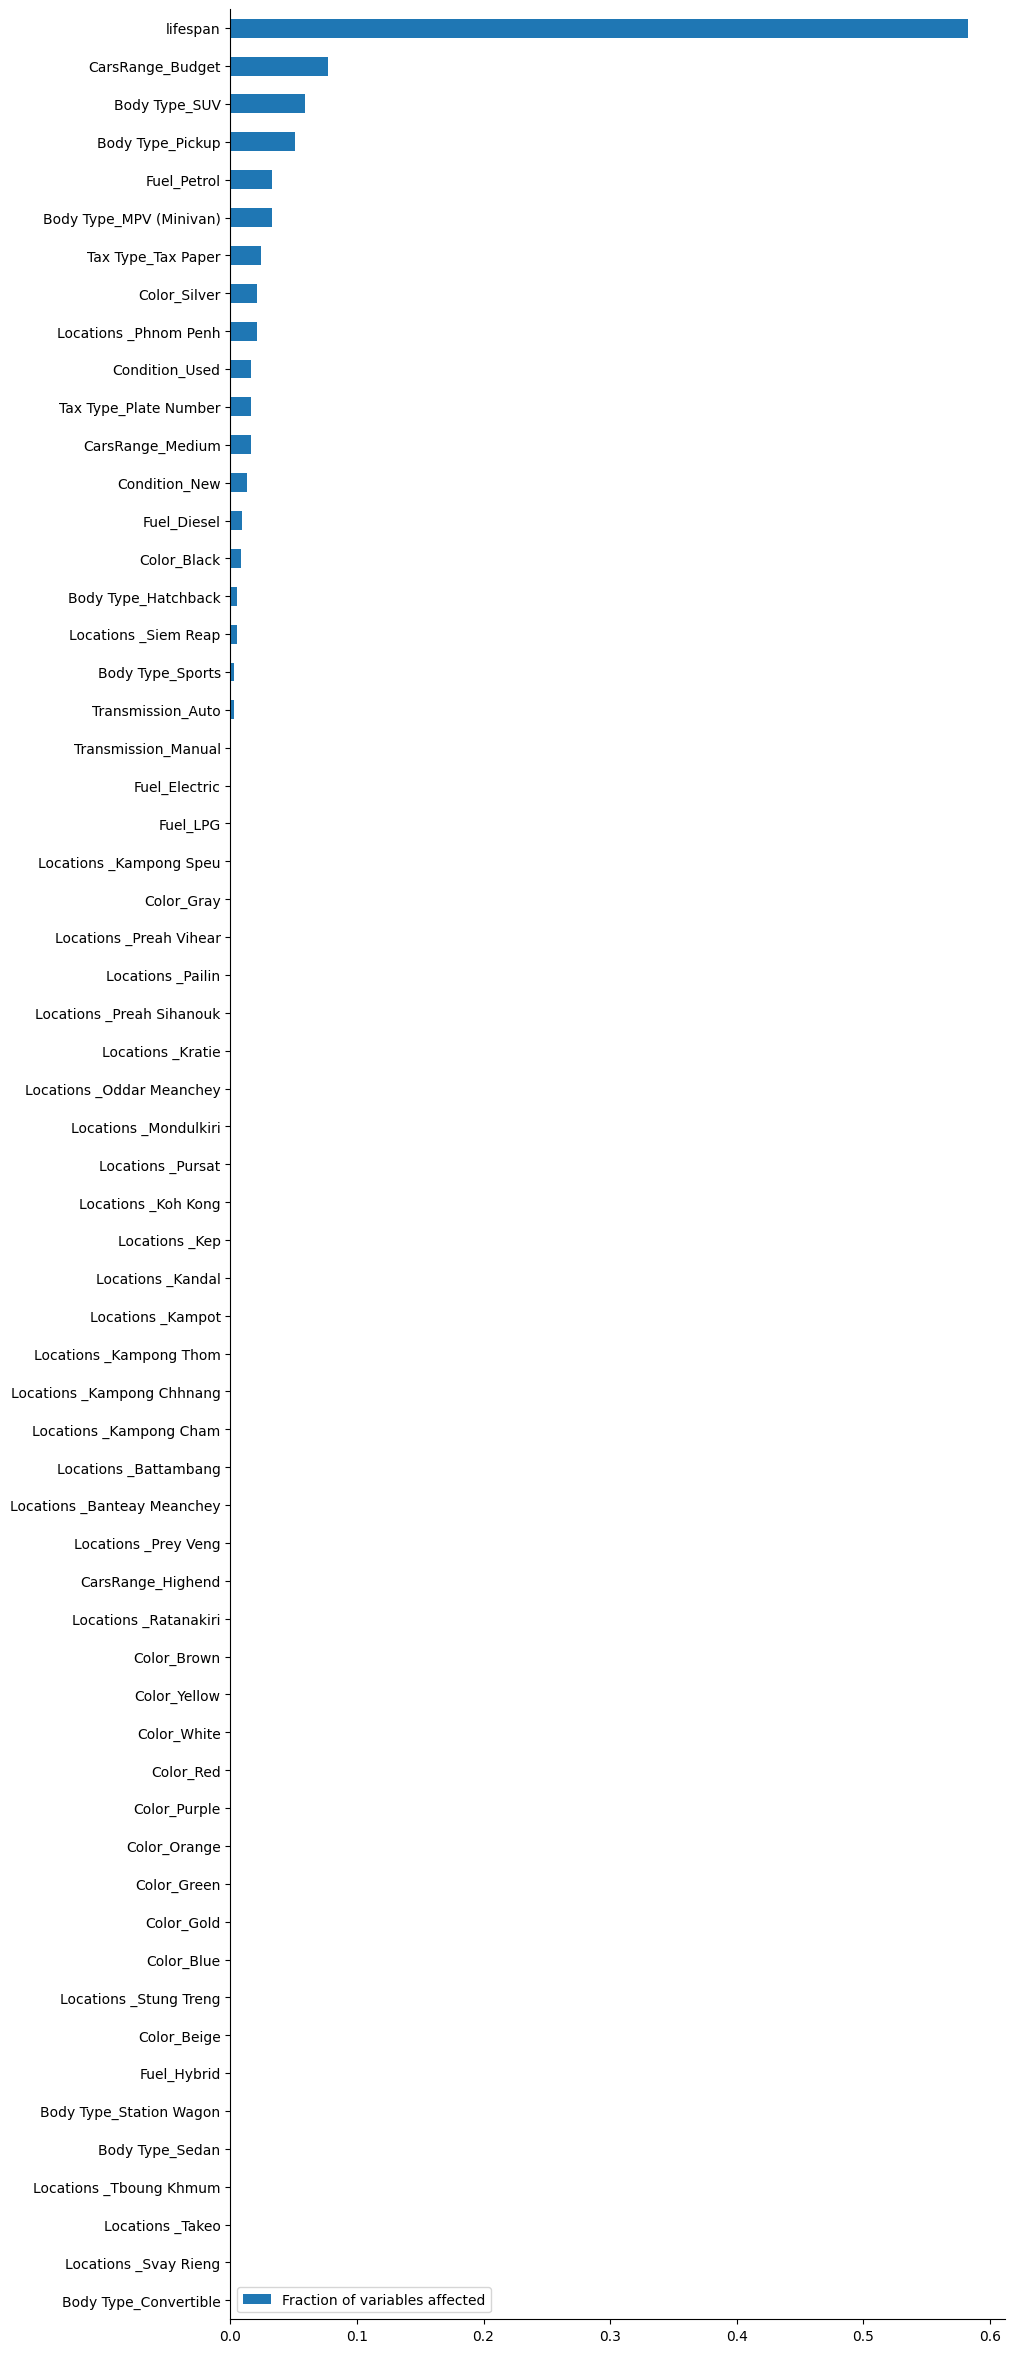

In [155]:
feature_import_random_forest(AdaBoostRegressor(), X_train, Y_train)

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<a id="1.3"></a>
<h2 style="font-family: Verdana; font-size: 22px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: black; background-color: #ffffff;"><b>6. Gradient-Boosting-Regressor </b> Model</h2>

In [156]:
from sklearn.ensemble import GradientBoostingRegressor
model_prediction(x_train, x_test, y_train, y_test, GradientBoostingRegressor(), 'GradientBoostingRegressor')

r2_Score of GradientBoostingRegressor() model on Training Data is: 88.50357767036395
r2_Score of GradientBoostingRegressor() model on Testing Data is: 85.60574666007678
MSE of GradientBoostingRegressor() model on Testing Data is: 0.04172493472744181


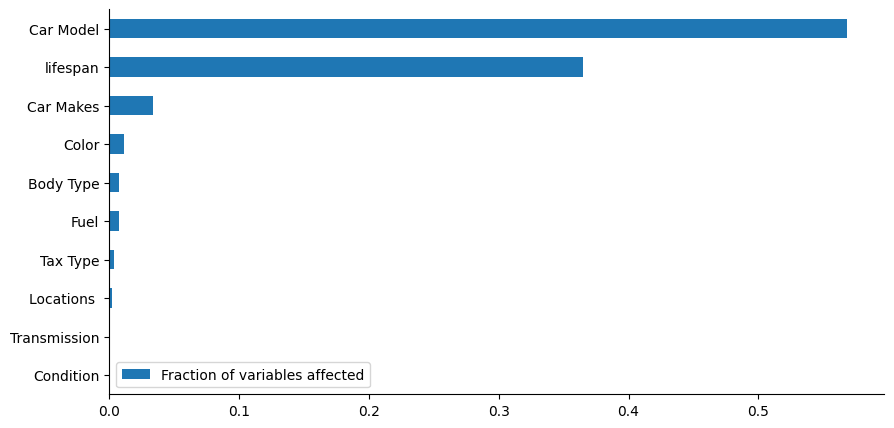

In [157]:
feature_import_random_forest(GradientBoostingRegressor(), x_train, y_train)

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<a id="1.3"></a>
<h2 style="font-family: Verdana; font-size: 22px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: black; background-color: #ffffff;"><b>7. LGMB Regressor </b> Model</h2>

In [158]:
from lightgbm import LGBMRegressor
model_prediction(x_train, x_test, y_train, y_test, LGBMRegressor(), 'LGBMRegressor')

r2_Score of LGBMRegressor() model on Training Data is: 93.65934011533767
r2_Score of LGBMRegressor() model on Testing Data is: 89.62432336802637
MSE of LGBMRegressor() model on Testing Data is: 0.030076199160772324


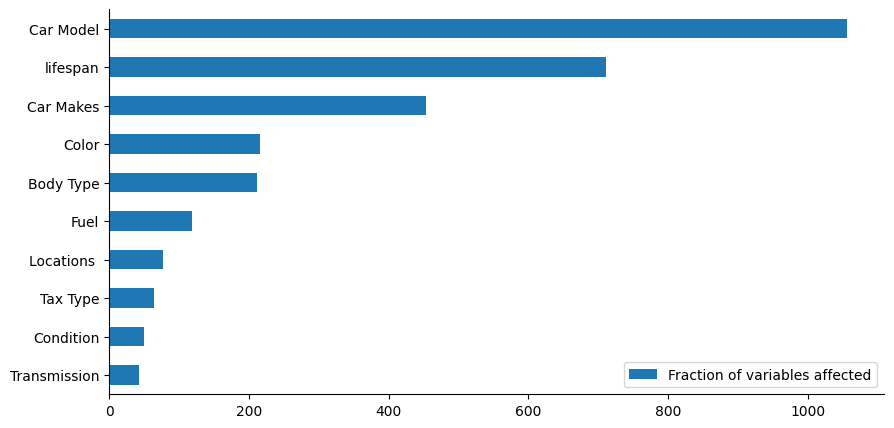

In [159]:
feature_import_random_forest(LGBMRegressor(), x_train, y_train)

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<a id="1.3"></a>
<h2 style="font-family: Verdana; font-size: 22px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: black; background-color: #ffffff;"><b>8. XGBRegressor </b> Model</h2>

In [160]:
from xgboost import XGBRegressor
model_prediction(x_train, x_test, y_train, y_test, XGBRegressor(), 'XGBRegressor')

r2_Score of XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=100, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=None, ...) model on Training Data is: 96.4899878759615
r2_Score of XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
       

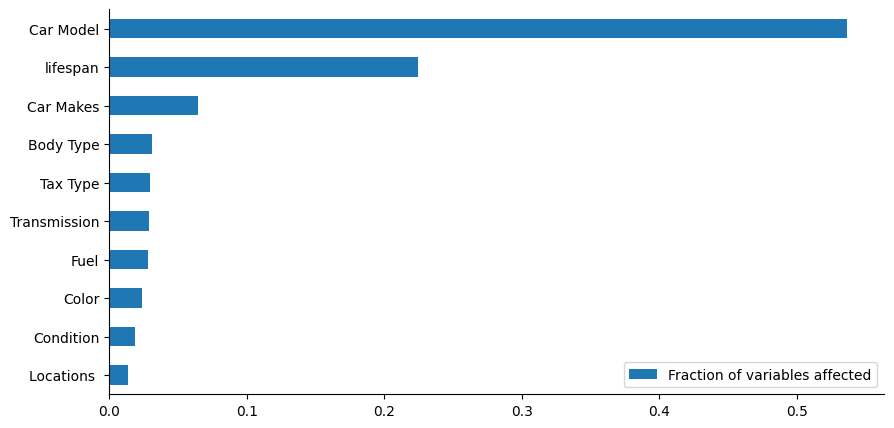

In [161]:
feature_import_random_forest(XGBRegressor(), x_train, y_train)

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<a id="1.3"></a>
<h2 style="font-family: Verdana; font-size: 22px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: black; background-color: #ffffff;"><b>9. Cat-Boost-Regressor </b> Model</h2>

In [162]:
from catboost import CatBoostRegressor
model_prediction(x_train, x_test, y_train, y_test, CatBoostRegressor(verbose= False), 'XGBRegressor')

r2_Score of <catboost.core.CatBoostRegressor object at 0x0000014C9648D300> model on Training Data is: 95.03293538017016
r2_Score of <catboost.core.CatBoostRegressor object at 0x0000014C9648D300> model on Testing Data is: 90.1787803383291
MSE of <catboost.core.CatBoostRegressor object at 0x0000014C9648D300> model on Testing Data is: 0.028468982700930557


Learning rate set to 0.056521
0:	learn: 0.5288799	total: 1.98ms	remaining: 1.97s
1:	learn: 0.5082742	total: 3.74ms	remaining: 1.86s
2:	learn: 0.4885549	total: 5.41ms	remaining: 1.8s
3:	learn: 0.4694918	total: 7.12ms	remaining: 1.77s
4:	learn: 0.4522769	total: 8.92ms	remaining: 1.77s
5:	learn: 0.4354416	total: 10.7ms	remaining: 1.77s
6:	learn: 0.4205358	total: 13.2ms	remaining: 1.87s
7:	learn: 0.4066672	total: 14.9ms	remaining: 1.84s
8:	learn: 0.3936805	total: 16.6ms	remaining: 1.83s
9:	learn: 0.3818658	total: 18.3ms	remaining: 1.81s
10:	learn: 0.3706256	total: 19.8ms	remaining: 1.78s
11:	learn: 0.3604312	total: 21.4ms	remaining: 1.76s
12:	learn: 0.3510413	total: 22.9ms	remaining: 1.74s
13:	learn: 0.3422081	total: 24.5ms	remaining: 1.73s
14:	learn: 0.3334296	total: 26ms	remaining: 1.71s
15:	learn: 0.3252489	total: 27.7ms	remaining: 1.7s
16:	learn: 0.3172618	total: 29.3ms	remaining: 1.69s
17:	learn: 0.3101536	total: 30.8ms	remaining: 1.68s
18:	learn: 0.3041731	total: 32.4ms	remaining: 1.

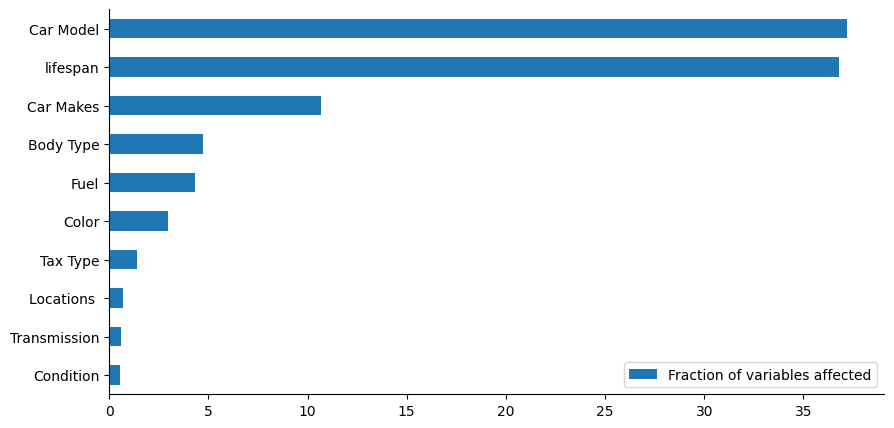

In [163]:
feature_import_random_forest(CatBoostRegressor(), x_train, y_train)

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<a id="1.3"></a>
<h2 style="font-family: Verdana; font-size: 22px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: black; background-color: #ffffff;"><b>10. Ridge Regressor </b> Model</h2>

In [164]:
from sklearn.linear_model import Ridge, RidgeCV

ridgecv = RidgeCV(alphas=np.logspace(-2, 3, num=50))
ridgecv.fit(x_train, y_train)
alpha = ridgecv.alpha_
model_prediction(x_train, x_test, y_train, y_test, Ridge(alpha=alpha), 'Ridge')

r2_Score of Ridge(alpha=1.3894954943731375) model on Training Data is: 78.34201338477743
r2_Score of Ridge(alpha=1.3894954943731375) model on Testing Data is: 75.73643729428048
MSE of Ridge(alpha=1.3894954943731375) model on Testing Data is: 0.07033331609798789


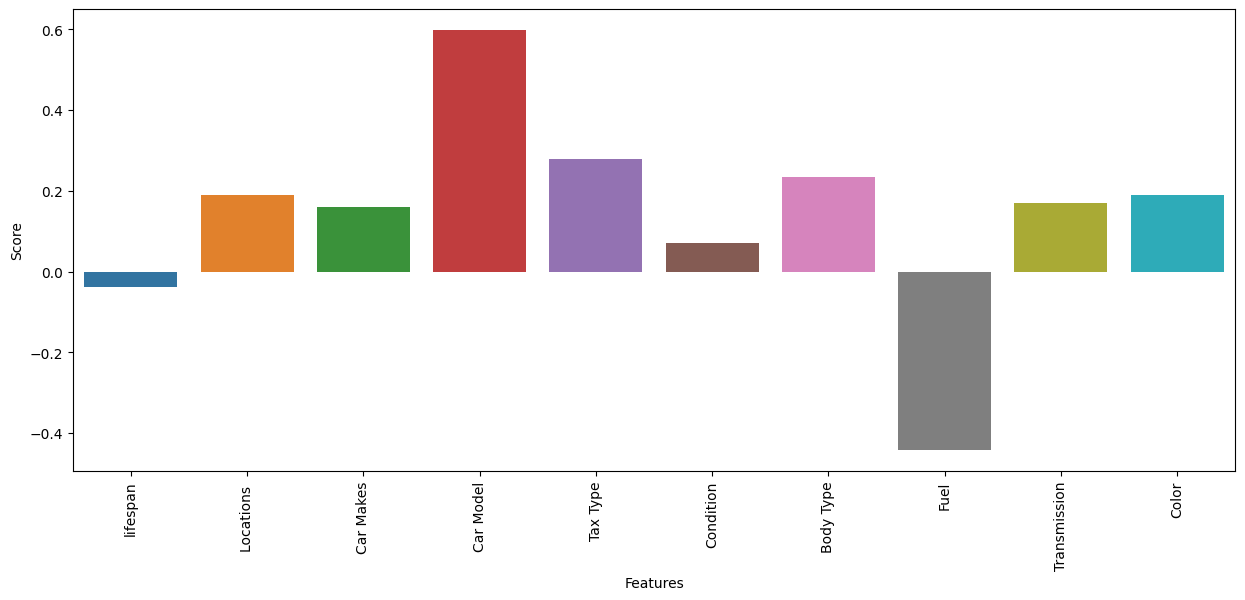

In [165]:
features_importance(x_train, y_train, Ridge(alpha=alpha))

r2_Score of Ridge(alpha=29.4705170255181) model on Training Data is: 70.33559646715497
r2_Score of Ridge(alpha=29.4705170255181) model on Testing Data is: 68.68483584553144
MSE of Ridge(alpha=29.4705170255181) model on Testing Data is: 0.09116145544901756


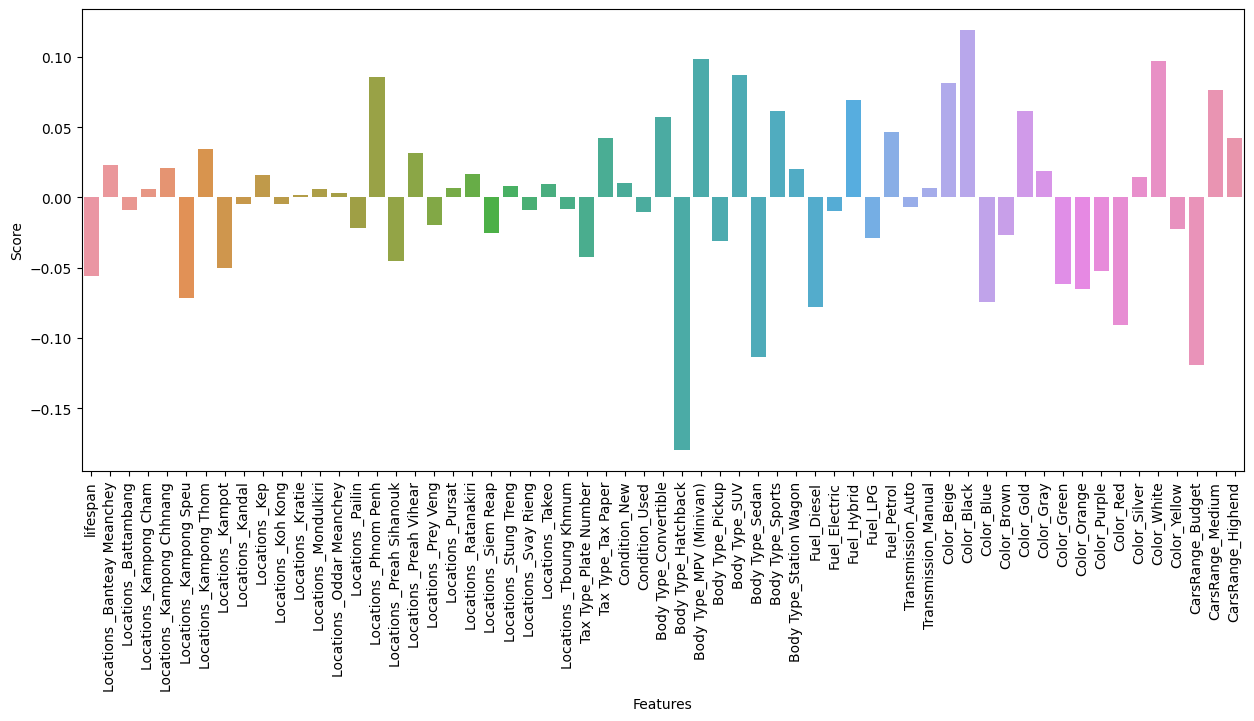

In [202]:
ridgecv = RidgeCV(alphas=np.logspace(-2, 3, num=50))
ridgecv.fit(X_train, Y_train)
alpha = ridgecv.alpha_
model_prediction(X_train, X_test, Y_train, Y_test, Ridge(alpha=alpha), 'Ridge')
features_importance(X_train, Y_train, Ridge(alpha=alpha))

---

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<a id="1.3"></a>
<h2 style="font-family: Verdana; font-size: 22px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: black; background-color: #ffffff;"><b>10. Lasso Regressor </b> Model</h2>

In [167]:
from sklearn.linear_model import Lasso, LassoCV

lasso_cv = LassoCV(alphas=np.logspace(-2, 3, num=50))
lasso_cv.fit(x_train, y_train)
alpha = lasso_cv.alpha_
model_prediction(x_train, x_test, y_train, y_test, Lasso(alpha=alpha), 'Ridge')

r2_Score of Lasso(alpha=0.01) model on Training Data is: 75.8431596192885
r2_Score of Lasso(alpha=0.01) model on Testing Data is: 73.35642938796859
MSE of Lasso(alpha=0.01) model on Testing Data is: 0.07723229669785196


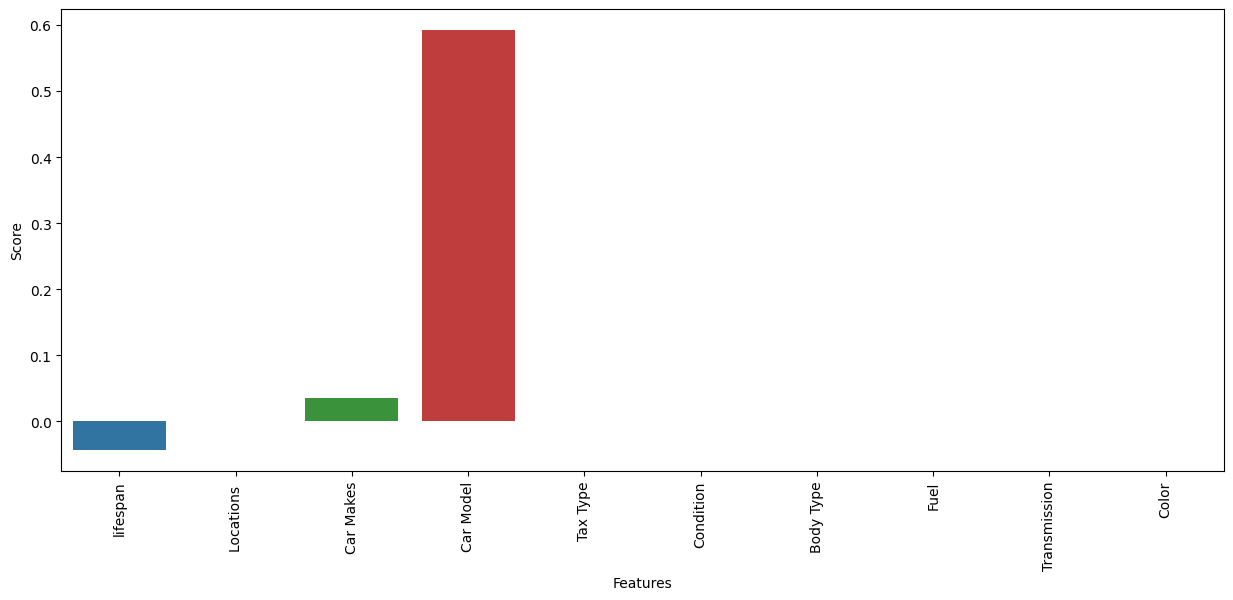

In [168]:
features_importance(x_train, y_train, Lasso(alpha=alpha))

In [169]:
lasso_cv = LassoCV(alphas=np.logspace(-2, 3, num=50))
lasso_cv.fit(X_train, Y_train)
alpha = lasso_cv.alpha_
model_prediction(X_train, X_test, Y_train, Y_test, Lasso(alpha=alpha), 'Ridge')

r2_Score of Lasso(alpha=0.01) model on Training Data is: 67.41998745862318
r2_Score of Lasso(alpha=0.01) model on Testing Data is: 64.99007405207496
MSE of Lasso(alpha=0.01) model on Testing Data is: 0.10191726247488792


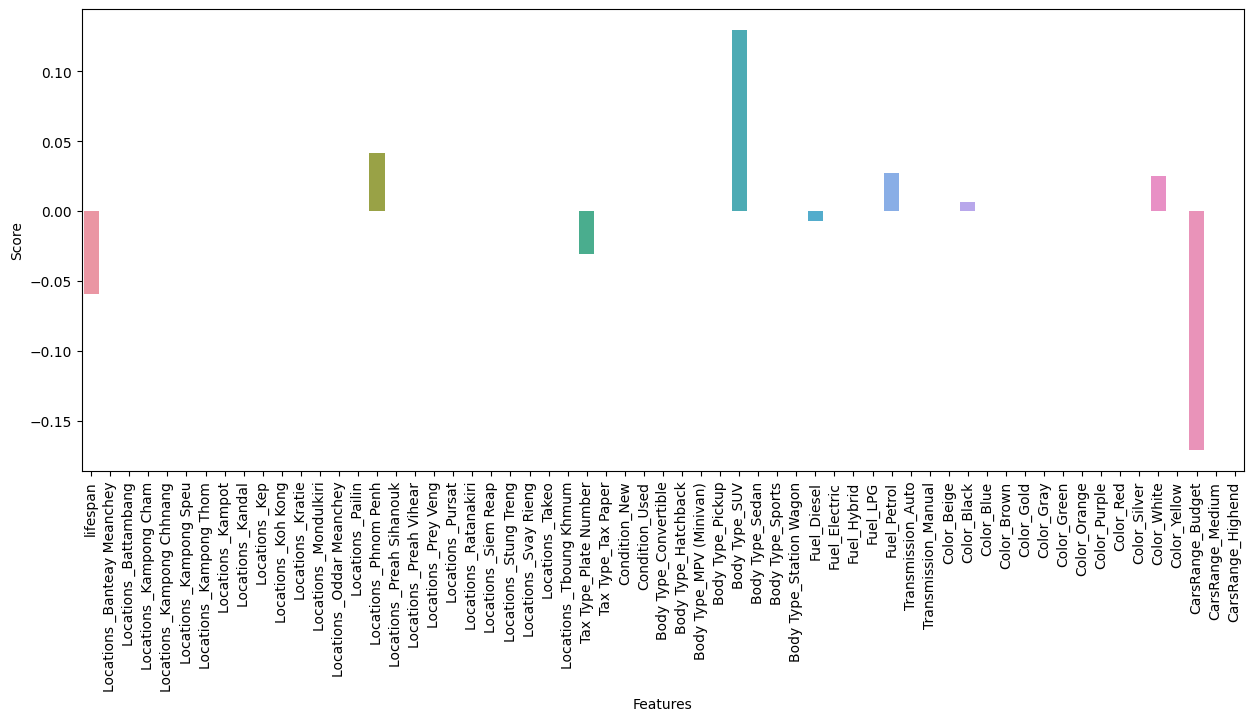

In [170]:
features_importance(X_train, Y_train, Lasso(alpha=alpha))

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:black;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
All Model Performance Comparison
</p>
</div>

In [171]:
df_model = pd.DataFrame.from_dict(Algorithms)
df_model

,Training Score,Testing Score,Algorithms
0,78.3426,75.7406,Linear Regression
1,70.3337,68.4965,Linear Regression with new_df
2,98.1491,83.5490,Decission Tree
3,91.2094,71.4027,Decission Tree
4,97.3184,88.6022,RandomForestRegressor
5,73.8174,69.6308,AdaBoostRegressor
6,88.5036,85.6057,GradientBoostingRegressor
7,93.6593,89.6243,LGBMRegressor
8,96.4900,89.7514,XGBRegressor
9,95.0329,90.1788,XGBRegressor


### Plotting above results using column-bar chart.

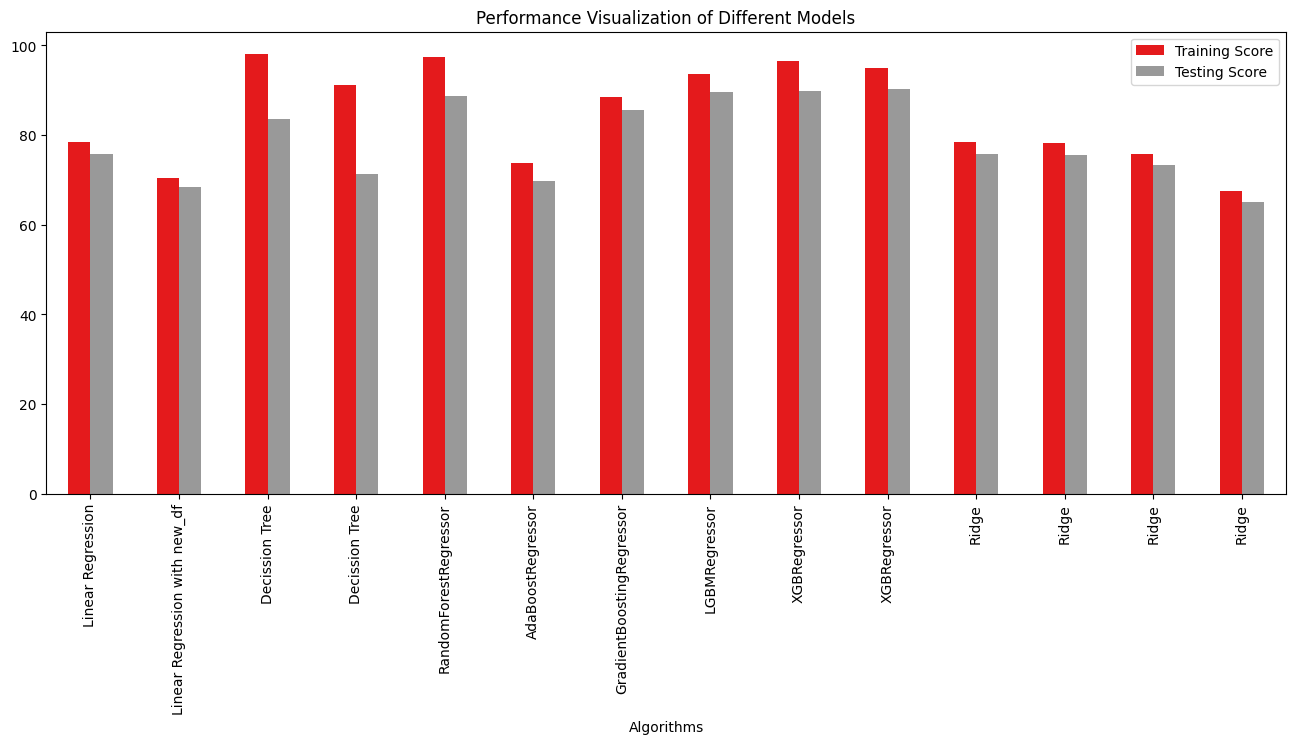

In [172]:
df_model.plot(x="Algorithms",y=["Training Score","Testing Score"], figsize=(16,6),kind="bar",
        title="Performance Visualization of Different Models",colormap="Set1")
plt.show()

---

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:black;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
Conclusion
</p>
</div>

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>